# Power spectra estimation: QML vs heracles pipeline (TR1)

In this notebook we adapt the QML power-spectrum pipeline to run on the real Euclid-like TR1 survey data (the effective-coverage mask, and the position/shear catalogues), for a single tomographic bin. We then compare the QML estimate against an independent NaMaster (PCl) estimate, and against heracles' own pipeline pseudo-Cl output for the same bin.

### Necessary imports

Please ensure that all Python requirements have already been installed. If not, this can be done through the usual package managers of `conda` or `pip`.

In [1]:
import os
import time
import numpy as np
import fitsio
from scipy import stats, constants
import healpy as hp
import pymaster as nmt

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.use('Agg')
plt.rcParams['text.usetex'] = False
sns.set(font_scale=1.25, rc={'text.usetex': False, 'figure.dpi': 300})

In [2]:
%matplotlib inline

Import custom code

In [3]:
# Add our custom code to the path such that Python can find it
import sys
root_filepath = '/home/vscode/WeakLensingQML'
sys.path.append(f'{root_filepath}')

# Now import it
from python.lib.PreProcessing.QMLClass import QML
from python.lib.PreProcessing.Y_matrix_class import YMatrix
from python.lib.PreProcessing.GenerateMask import generate_mask, plot_mask
from python.lib.CppInterface.GeneratePowerSpectra import PowerSpec
from python.lib.CppInterface.GenerateCppConstants import generate_constants_h
from python.lib.CppInterface.CppLib import CppLib

# heracles is used to read the pipeline's own catalogues/outputs for comparison
import heracles

## Generic information about the maps

Here, we specify the HealPix $N_\textrm{side}$ parameter for our maps. As a reminder, the maximum multipole that can be computed from a map with resolution $N_\textrm{side}$ is $3 \times N_\textrm{side} - 1$, with the maximum reliable multipole being $\ell_{\textrm{max}} = 2 N_\textrm{side}$.

In [42]:
n_side = 512

# Derived quantities
n_pix = 12 * n_side * n_side

# The QML/NaMaster analysis multipole range is *decoupled* from n_side here. The real TR1
# survey patch covers only ~0.4% of the sky, which cannot support unbinned per-ell estimates
# anywhere near the HEALPix-limited l_max = 3 * n_side - 1 (the pixel covariance matrix
# becomes extremely ill-conditioned as l_max approaches this ceiling). Note l_max_full=1000
# only keeps a ~35% margin below the ceiling (1000 / (3*512-1) = 0.651) - less conservative
# than the ~52% margin used at n_side=64/128 - so watch for conditioning issues (e.g. a
# near-singular Fisher matrix) when this is first run at the new resolution.

l_max_full = 1000
ells_full = np.arange(2, l_max_full + 1)
n_ell_full = len(ells_full)

# Kept as aliases so that existing per-ell code below still works unchanged; we no longer
# have a separate "reliable" sub-range since l_max_full is now well below the n_side-imposed
# HEALPix limit of 3 * n_side - 1.
l_max = l_max_full
ells = ells_full
n_ell = n_ell_full

In [43]:
# TR1-specific configuration: real Euclid-like survey data (coverage mask + position/shear
# catalogues) from the local heracles pipeline run, restricted to a single tomographic bin.
tr1_dir = f'{root_filepath}/TR1'
pipeline_input_dir = f'{tr1_dir}/pipeline_input'
pipeline_output_dir = f'{tr1_dir}/pipeline_output'
tr1_data_dir = f'{tr1_dir}/data'

os.makedirs(tr1_data_dir, exist_ok=True)
os.makedirs(f'{tr1_data_dir}/masks', exist_ok=True)

# Tomographic bin used for this comparison (POS_TOM_BIN_ID / TOM_BIN_ID)
tom_bin = 1

coverage_filepath = f'{pipeline_input_dir}/EUC_LE3_VMPZ-ID_HPEFFECTIVECOVERAGE-CONCAT-20251204T094108.787432Z_0.12.fits'
she_catalog_filepath = f'{pipeline_input_dir}/EUC_LE3_WLCATALOG-CONCAT-20251218T164508.418188Z_00.00.fits'

## Mask generation

Rather than a synthetic mask, we build our mask directly from the real Euclid effective-coverage map used by the pipeline, downgraded to our QML `n_side` and binarised (the QML C++ code only supports a binary in/out mask, not a continuous weight map).

In [44]:
def read_partial_map(path, nside, *, nest=False):
    """
    Read a HEALPix map in "partial" format from *path* and return it at resolution *nside*.
    The returned NSIDE cannot be larger than the NSIDE of the stored map.
    """
    data, header = fitsio.read(path, header=True)
    nside_in = header['NSIDE']
    fact = (nside_in // nside) ** 2
    if fact == 0:
        raise ValueError(f'requested NSIDE={nside} greater than map NSIDE={nside_in}')
    out = np.zeros(12 * nside ** 2)
    ipix, wht = data['PIXEL'], data['WEIGHT']
    order = header['ORDERING']
    if order == 'RING':
        ipix = hp.ring2nest(nside_in, ipix)
    elif order != 'NESTED':
        raise ValueError(f'unknown pixel ordering {order} in map')
    ipix = ipix // fact
    if not nest:
        ipix = hp.nest2ring(nside, ipix)
    np.add.at(out, ipix, wht / fact)
    return out


# Read the real effective-coverage map and downgrade it directly to our QML resolution
coverage = read_partial_map(coverage_filepath, n_side)
mask = (coverage > 0)

f_sky = mask.sum() / mask.size
print(f'The f_sky of the real survey mask (n_side={n_side}) is {(f_sky * 100):.3f} %')

The f_sky of the real survey mask (n_side=512) is 0.351 %


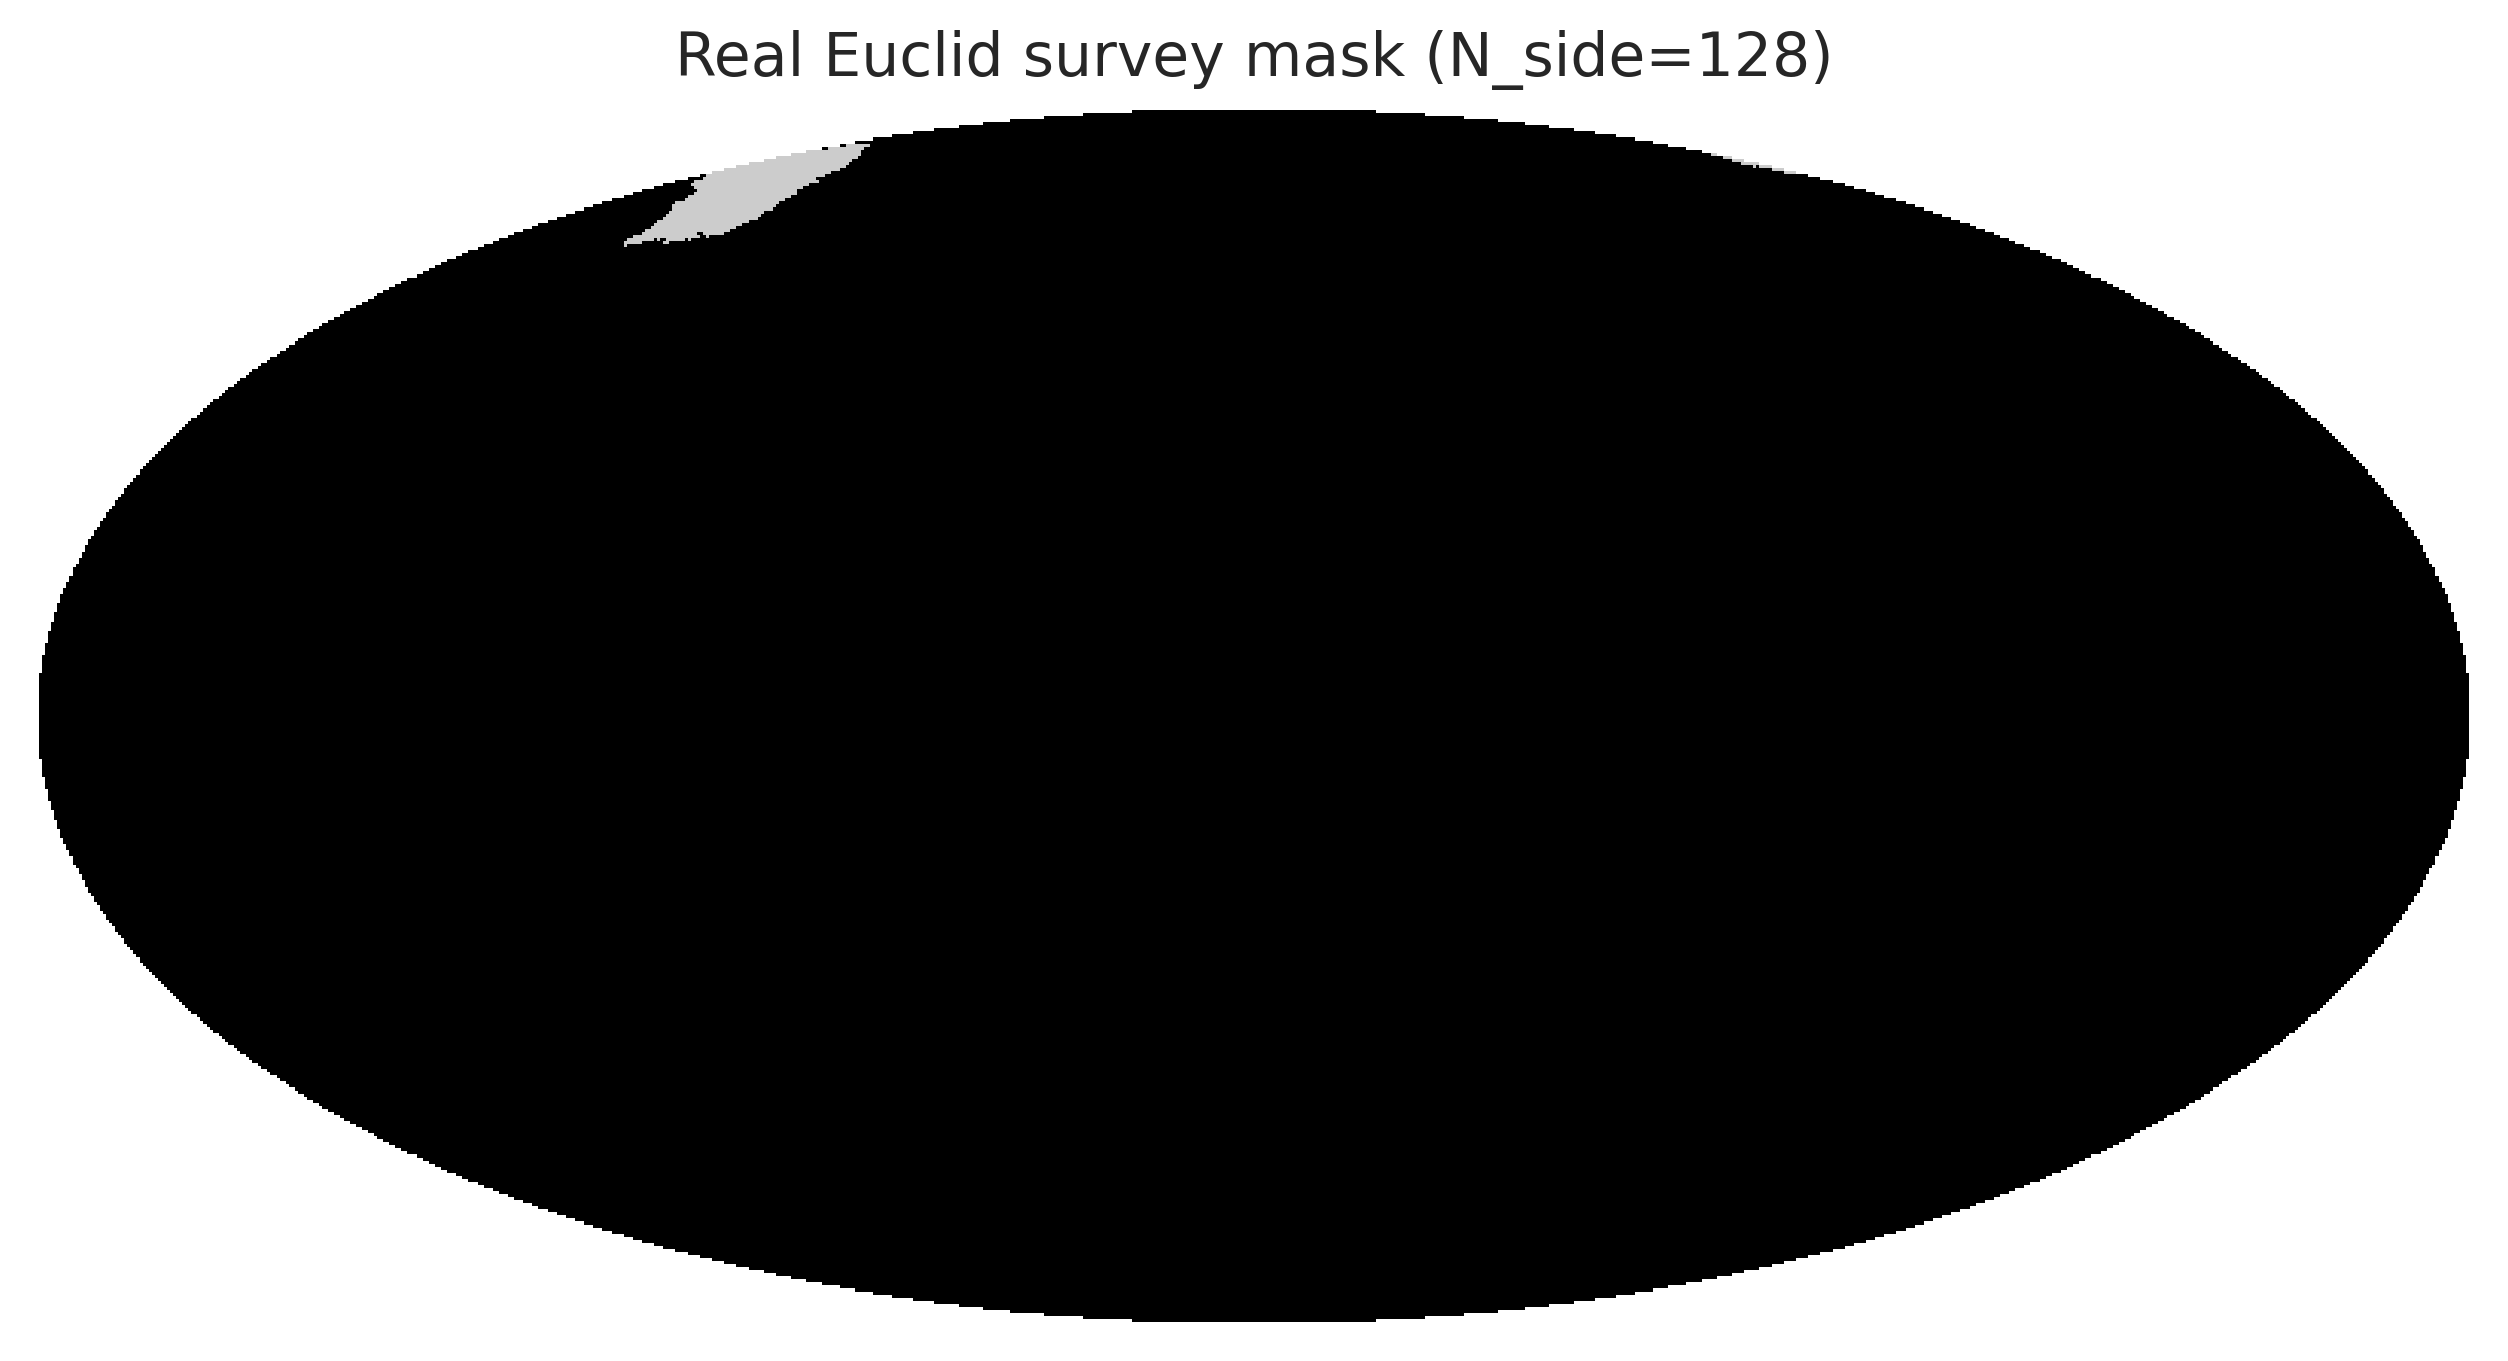

In [7]:
# Now plot this mask
plt.rcParams['text.usetex'] = False
hp.mollview(mask, cmap='nipy_spectral', cbar=False, title=f'Real Euclid survey mask (N_side={n_side})')
plt.show()

In [45]:
# Now save this mask to our TR1 data directory
mask_filepath = f'{tr1_data_dir}/masks/SkyMask_TR1_N{n_side}.fits'
hp.write_map(mask_filepath, mask.astype(float), overwrite=True, fits_IDL=False, dtype=np.float64)

## Bandpower binning

This survey patch is far too small to support unbinned per-ell QML/NaMaster estimates, or even the ~30 log-spaced bins used by heracles for its (much larger) footprint. With $f_\mathrm{sky}=0.437\%$, the number of independent sky modes at multipole $\ell$ is only $(2\ell+1) f_\mathrm{sky}$ - summed over $\ell=10$ to $\ell_\mathrm{max}$ that's only ~44 modes *total*, so most of heracles' narrow low-$\ell$ bins would contain well under 1 independent mode each, making a single-realization $C_\ell$ estimate in such a bin essentially undefined (huge swings, even sign flips).

Instead, we choose a small number of bandpowers whose edges are spaced so that each bin contains a roughly *equal number of independent modes* (rather than equal $\ell$-width or log-spacing), directly using this patch's real $f_\mathrm{sky}$. The binning matrix defined here is applied to the QML Fisher matrix/$y_\ell$ values *before* inverting (rather than inverting the near-singular unbinned Fisher matrix and binning afterwards), and the same bin edges are used to build the NaMaster bandpower object, so that all three pipelines are compared on a consistent $\ell$ grid.


In [46]:
n_bandpowers = 8
ells_for_binning = np.arange(10, l_max_full + 1)
modes_per_ell = (2 * ells_for_binning + 1) * f_sky
cum_modes = np.cumsum(modes_per_ell)

# Choose bin edges so each bandpower contains a roughly equal number of independent modes
targets = np.linspace(0, cum_modes[-1], n_bandpowers + 1)[1:-1]
ell_bp_edges = [10] + [int(ells_for_binning[np.searchsorted(cum_modes, t)]) for t in targets] + [l_max_full + 1]
ell_bp_edges = np.array(sorted(set(ell_bp_edges)))
ell_bp_ini = ell_bp_edges[:-1]
ell_bp_end = ell_bp_edges[1:]
n_bands = len(ell_bp_ini)

# Binning (Jacobian) matrix mapping the unbinned ells_full grid onto our bandpowers.
# For a flat bandpower model (C_ell = C_b for ell in bin b), d(C_ell)/d(C_b) = 1, so this
# must be an unweighted 0/1 indicator - NOT a 1/N average - since it is applied as the
# congruence transform on the Fisher matrix (F_b = W^T F W) and as a plain sum on y_ell
# (y_b = W^T y). Using a 1/N-normalised matrix on both sides (as before) silently inflates
# the recovered C_b by an extra factor of N_b (the number of raw ells in that bin).
bin_matrix = np.zeros((n_bands, n_ell_full))
for b in range(n_bands):
    in_bin = (ells_full >= ell_bp_ini[b]) & (ells_full < ell_bp_end[b])
    bin_matrix[b, in_bin] = 1.0

# Block-diagonal version (EE then BB) used to bin the QML Fisher matrix/y_ell values
bin_matrix_EB = np.zeros((2 * n_bands, 2 * n_ell_full))
bin_matrix_EB[0: n_bands, 0: n_ell_full] = bin_matrix
bin_matrix_EB[n_bands: 2 * n_bands, n_ell_full: 2 * n_ell_full] = bin_matrix

# NaMaster bandpower object, built from the same bin edges, so QML and NaMaster share ells
bins = nmt.NmtBin.from_edges(ell_bp_ini, ell_bp_end)
ell_bp = bins.get_effective_ells()


## Compute and save the fiducial power spectrum

As the QML estimator requires an estimate for the power spectrum of the maps that wish to be processed, we need to compute and save it to the disk here.

Here, we use the Core Cosmology Library (CCL) to compute this.

We also need to specify the redshift range of sources in our analysis. Here, we take this as a Gaussian distribution centred at $z=1.0$ with a standard deviation of $\sigma_{z} = 0.15$

Note: since we don't know the true cosmology of the real TR1 data, this is only used as a fiducial/proxy spectrum to precondition and weight the QML estimator - it does not need to exactly match the real data for the estimator to remain valid (just to be reasonably close, for near-optimal error bars).

In [48]:
# First set up some fiducial cosmology values
fiducial_cosmology = {'h': 0.7, 'Omega_c': 0.27, 'Omega_b': 0.045, 'sigma8': 0.75, 'n_s': 0.96,
                      'm_nu': 0.0, 'T_CMB': 2.7255, 'w0': -1.0, 'wa': 0.0}

# Now set up our redshift distribution of galaxies
redshift_range = np.linspace(0.0, 3.0, 500)
redshift_dist = stats.norm.pdf(redshift_range, loc=1.0, scale=0.15)

# Output file path
cl_file_path = f'{tr1_data_dir}/TheorySpectra_TR1_N{n_side}.dat'

# Set up our PowerSpec class and compute the theory spectra
pow_spec = PowerSpec(n_side, fiducial_cosmology, redshift_range, redshift_dist, cl_file_path)

pow_spec.compute_power_spec()

Evaluating the theory Cl values using CCL
Saved the power spectrum to /home/vscode/WeakLensingQML/TR1/data/TheorySpectra_TR1_N512.dat


As the intrinsic ellipticity of galaxies introduces a shot-noise term to the cosmic shear power spectrum, we need to estimate it here. Rather than assuming fiducial values, we measure the (weighted) intrinsic ellipticity dispersion and effective galaxy number density directly from the real shear catalogue, for our chosen tomographic bin.

In [49]:
# Read only the columns/rows we need for the chosen tomographic bin
she_cols = ['SHE_RA', 'SHE_DEC', 'SHE_E1_CORRECTED', 'SHE_E2_CORRECTED', 'SHE_WEIGHT', 'TOM_BIN_ID']
she_data = fitsio.read(she_catalog_filepath, columns=she_cols)
she_data = she_data[she_data['TOM_BIN_ID'] == tom_bin]

she_weight = she_data['SHE_WEIGHT'].astype(np.float64)
she_e1 = -she_data['SHE_E1_CORRECTED'].astype(np.float64)  # Sign matches the pipeline's SHE field definition
she_e2 = she_data['SHE_E2_CORRECTED'].astype(np.float64)

# Weighted per-component intrinsic ellipticity dispersion, measured directly from the catalogue
sigma_e2 = np.sum(she_weight * (she_e1 ** 2 + she_e2 ** 2)) / (2 * np.sum(she_weight))

# Effective number of galaxies in this tomographic bin (accounts for weight variance)
n_eff = np.sum(she_weight) ** 2 / np.sum(she_weight ** 2)

# Sky area covered by our real mask, in steradians
area_mask = mask.sum() / mask.size * 4 * np.pi

# Theory noise power spectrum (shot-noise), in the same units as pow_spec.cl_EE
cl_noise = sigma_e2 / (n_eff / area_mask)

# Average effective number of galaxies per unmasked HEALPix pixel, and the associated
# map-domain per-pixel noise variance required by the QML C++ code
num_gal_per_pix = n_eff / mask.sum()
noise_var = sigma_e2 / num_gal_per_pix

## Quickly plot the power spectra

Now just plot the saved power spectra 

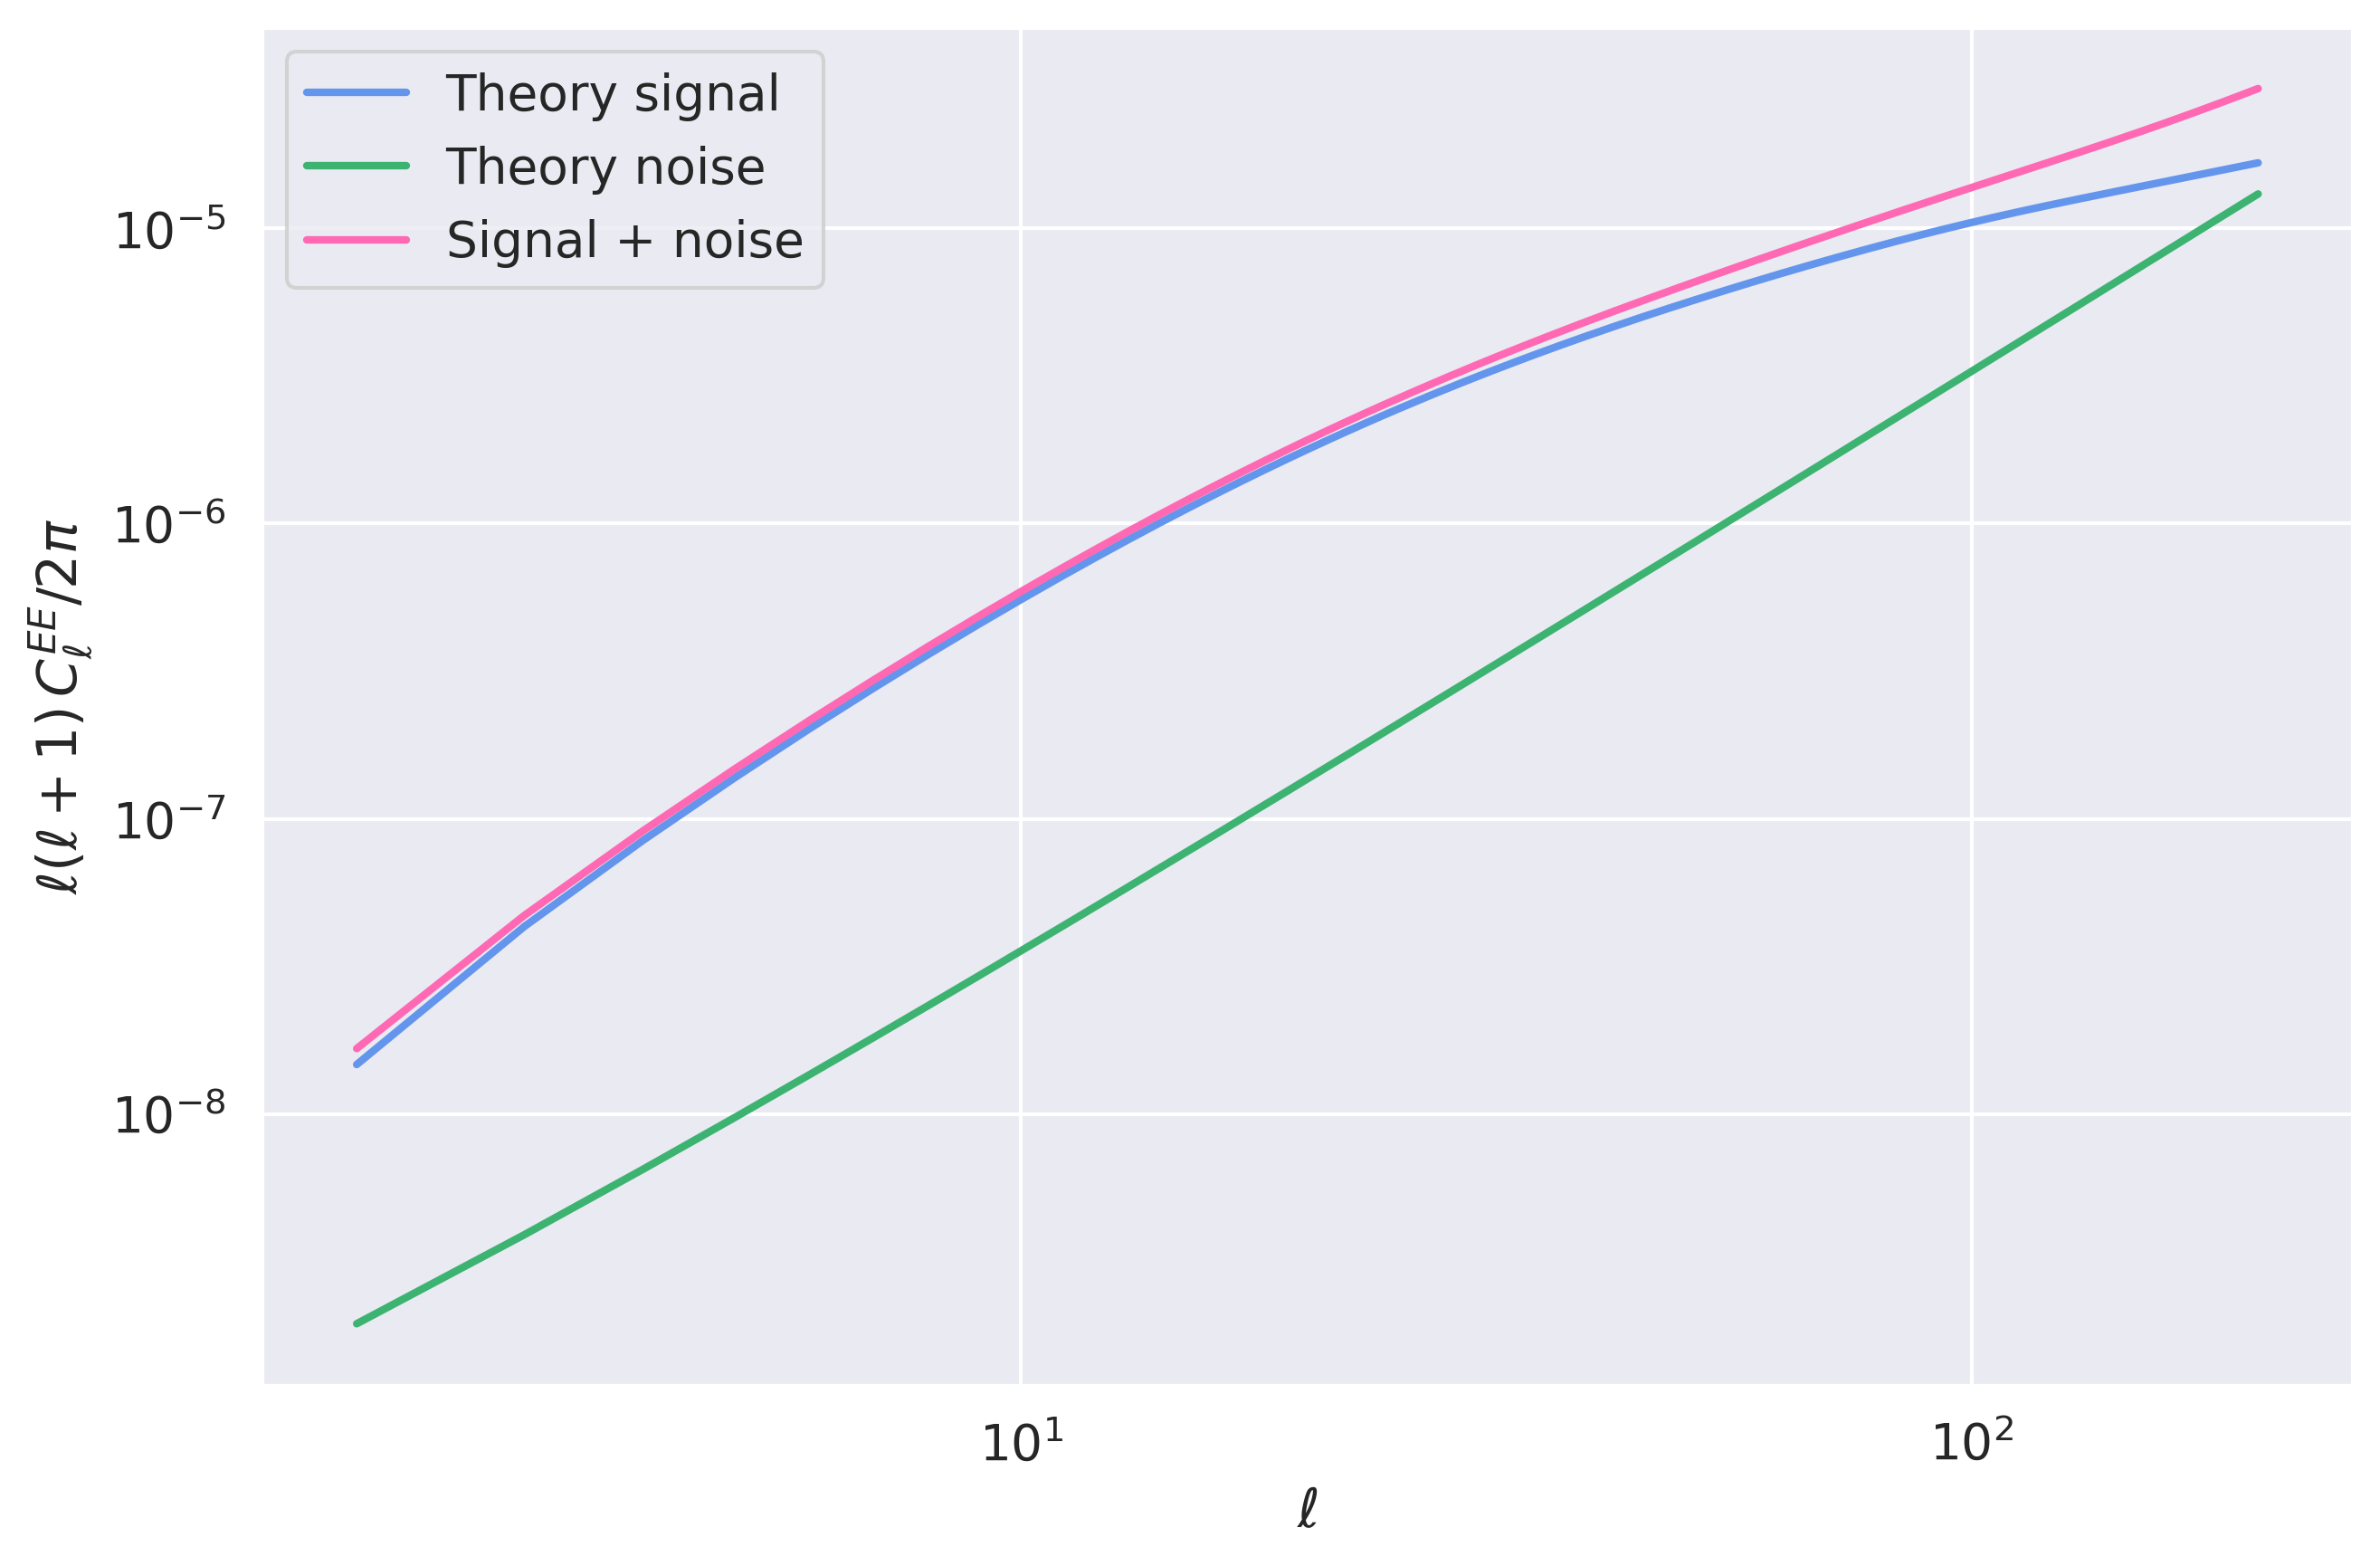

In [12]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ells, ells * (ells + 1) * pow_spec.cl_EE[2: l_max + 1] / (2 * np.pi), lw=2, c='cornflowerblue', label='Theory signal')
ax.loglog(ells, ells * (ells + 1) * cl_noise / (2 * np.pi), lw=2, c='mediumseagreen', label='Theory noise')
ax.loglog(ells, ells * (ells + 1) * (pow_spec.cl_EE[2: l_max + 1] + cl_noise) / (2 * np.pi), lw=2, c='hotpink', label='Signal + noise')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()

## Build the real shear (gamma1, gamma2) maps from the Euclid catalogue

Instead of a mock Gaussian simulation, we now pixelise the real shear catalogue (for our chosen tomographic bin) onto a HEALPix map at our QML resolution. This is the map whose power spectrum we want to estimate with the QML and NaMaster (PCl) methods, and compare against heracles' own pipeline output.

In [50]:
# Pixelise the real shear catalogue onto a HEALPix map at our QML resolution
she_ra = she_data['SHE_RA'].astype(np.float64)
she_dec = she_data['SHE_DEC'].astype(np.float64)

she_pix = hp.ang2pix(n_side, she_ra, she_dec, lonlat=True)

sum_weight = np.zeros(n_pix)
sum_weight_e1 = np.zeros(n_pix)
sum_weight_e2 = np.zeros(n_pix)

np.add.at(sum_weight, she_pix, she_weight)
np.add.at(sum_weight_e1, she_pix, she_weight * she_e1)
np.add.at(sum_weight_e2, she_pix, she_weight * she_e2)

# Weighted average shear per pixel (left as zero where there are no galaxies)
map_gamma1 = np.divide(sum_weight_e1, sum_weight, out=np.zeros(n_pix), where=sum_weight > 0)
map_gamma2 = np.divide(sum_weight_e2, sum_weight, out=np.zeros(n_pix), where=sum_weight > 0)

# Now apply our real survey mask
map_gamma1 *= mask
map_gamma2 *= mask

# Save the shear maps to disk for the QML C++ code
map_gamma1_path = f'{tr1_data_dir}/Map_TR1_N{n_side}_gamma1.fits'
map_gamma2_path = f'{tr1_data_dir}/Map_TR1_N{n_side}_gamma2.fits'

hp.write_map(map_gamma1_path, map_gamma1, overwrite=True, fits_IDL=False, dtype=np.float64)
hp.write_map(map_gamma2_path, map_gamma2, overwrite=True, fits_IDL=False, dtype=np.float64)

We can now plot our real cosmic shear map!

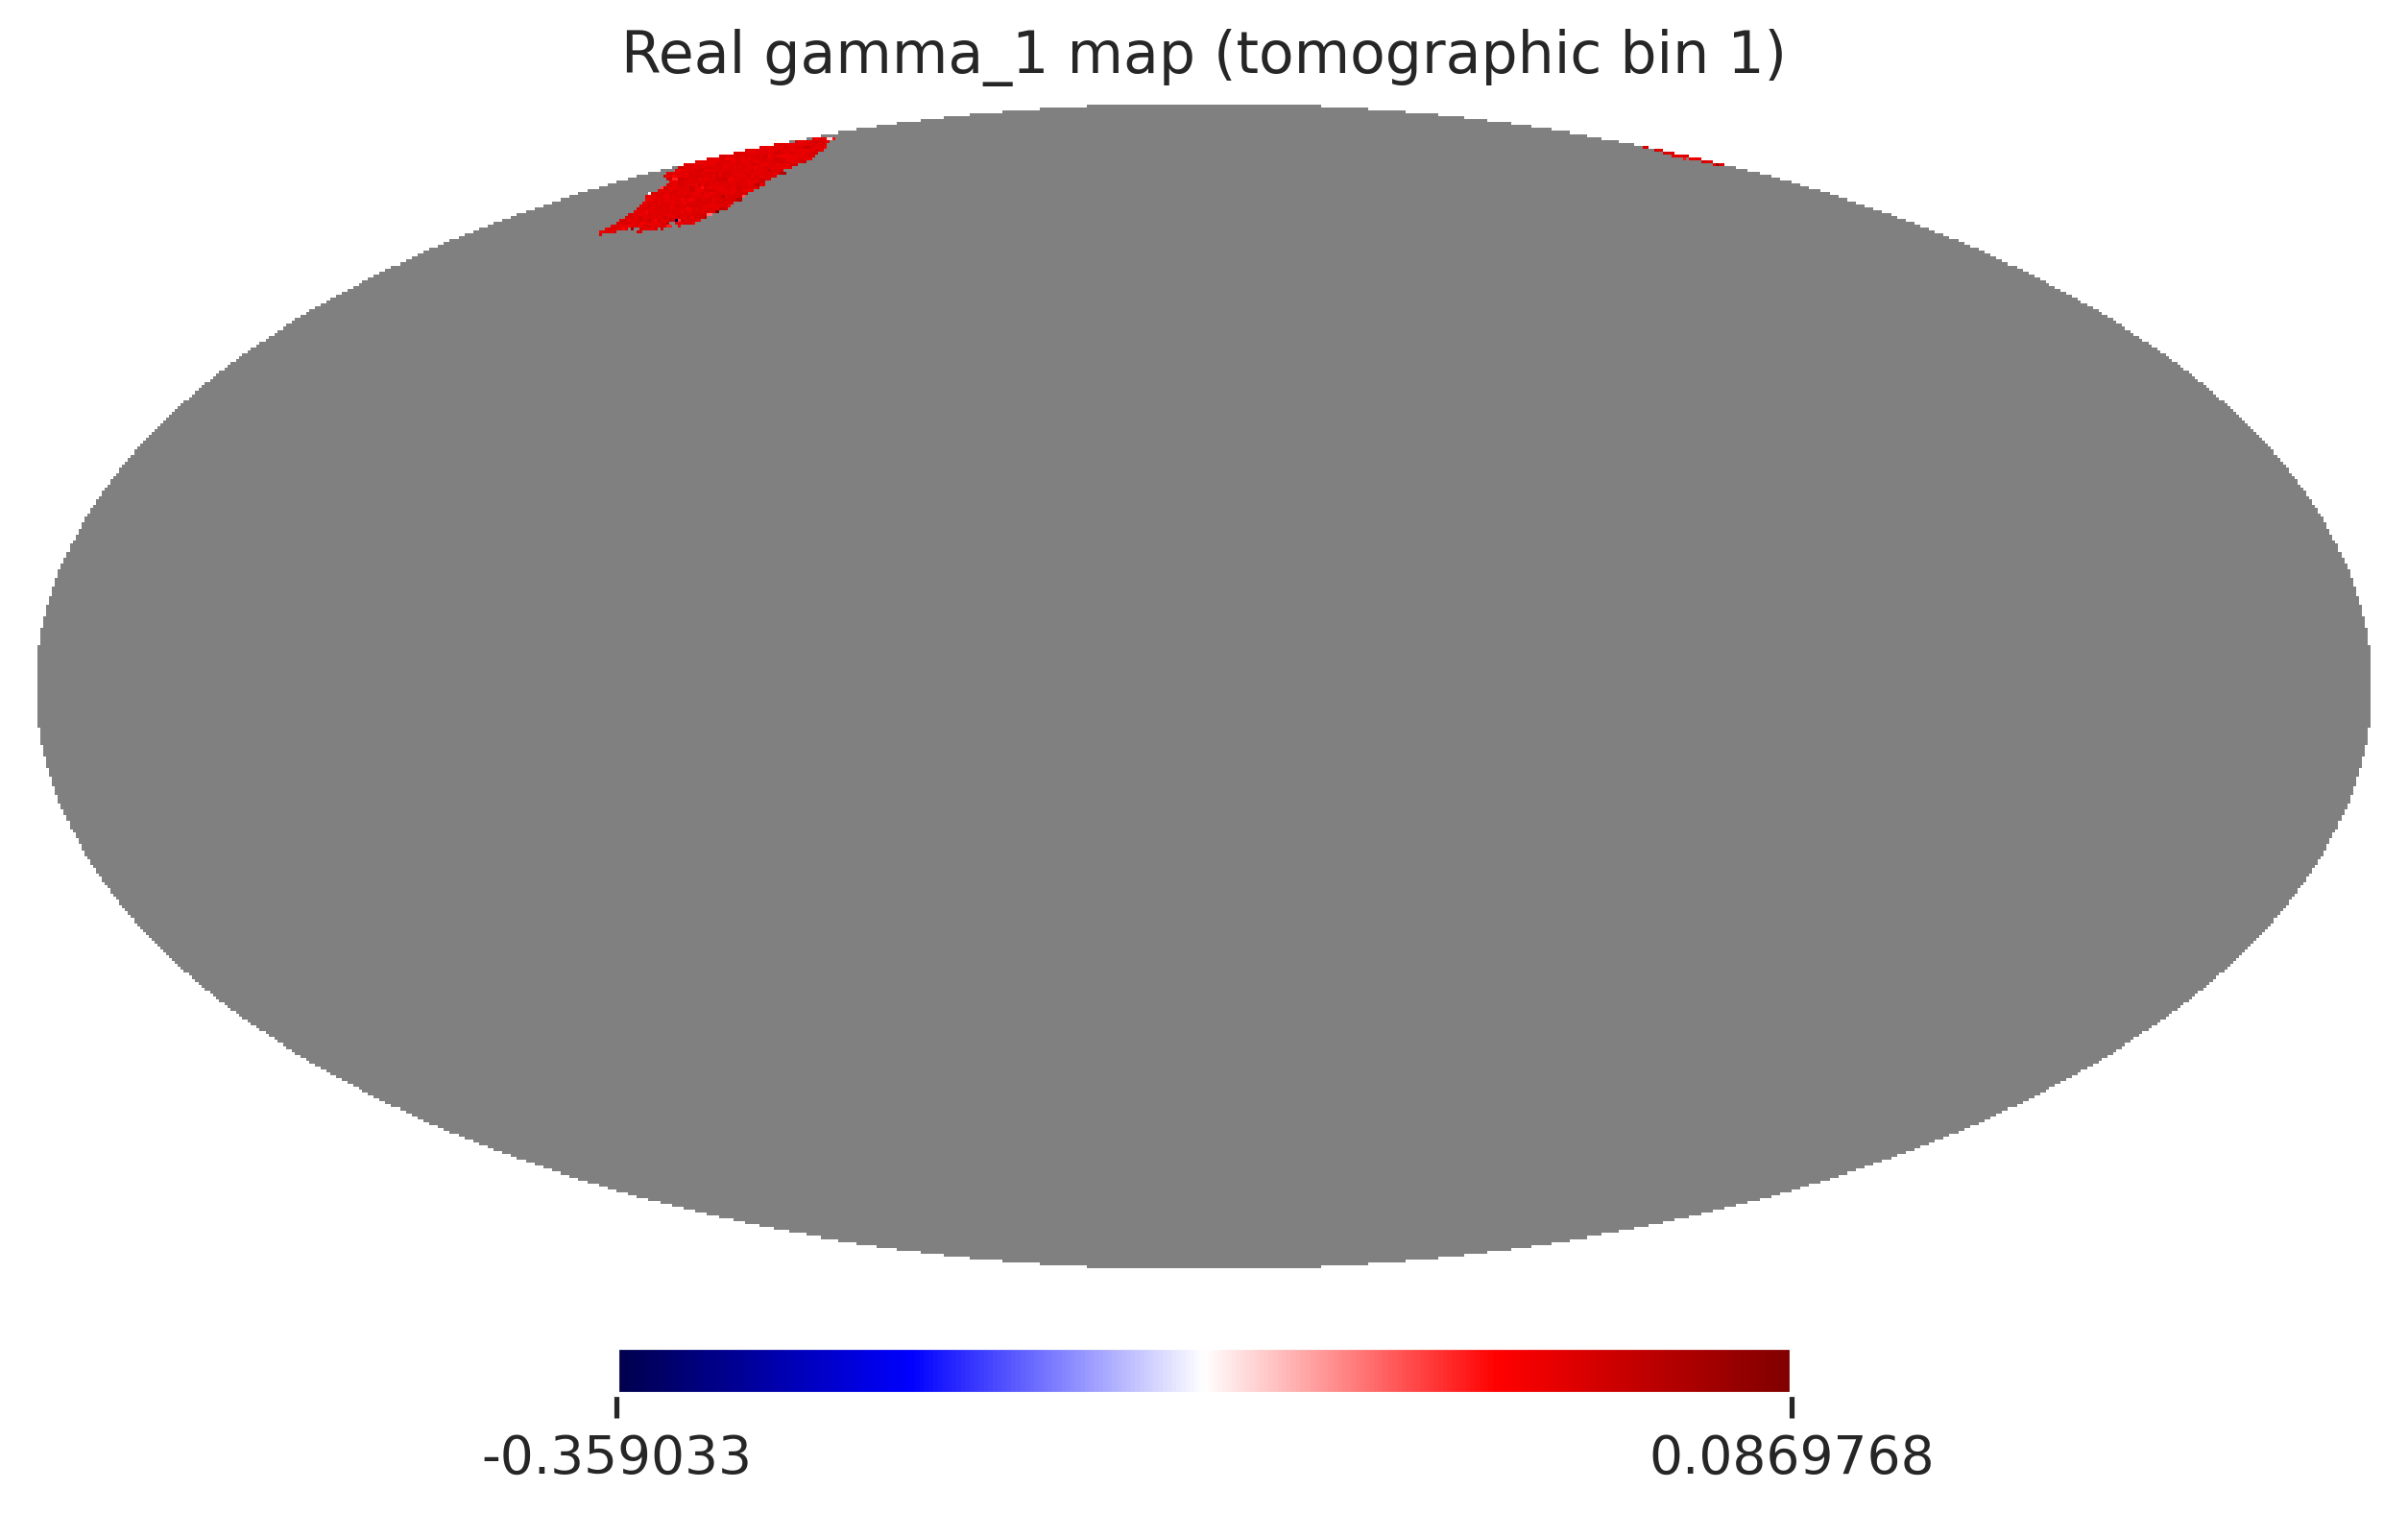

In [14]:
plot_map_gamma1 = map_gamma1.copy()
plot_map_gamma1[plot_map_gamma1 == 0] = np.nan

plt.rcParams['text.usetex'] = False
hp.mollview(plot_map_gamma1, cmap='seismic', cbar=True, title=f'Real gamma_1 map (tomographic bin {tom_bin})')

## Load in the C++ library

We now need to load in the C++ library which contains the core QML algorithm for both estimating the covariance matrix and using that to estimate the power spectrum of our masked map.

The `num_maps` parameter determines how many maps we should average over when computing the estimate for the Fisher
matrix. The more maps the more accurate the final estimation will be, though with fewer maps the results will be unbiased. Please check our reference paper for a detailed discussion of this topic.

In [ ]:
num_maps = 10  # reduced from 50 for a faster first timing test at the new n_side/l_max

In [51]:
# First, generate the "constants.h" file that is necessary for the C++ code to compile (and thus run)
# l_max_full is passed explicitly since it is decoupled from n_side (see the discussion above
# about why this small real mask cannot support unbinned per-ell estimates up to 3*n_side-1)

# Reload in case this module was imported before generate_constants_h gained the l_max argument
import importlib
from python.lib.CppInterface import GenerateCppConstants
importlib.reload(GenerateCppConstants)
from python.lib.CppInterface.GenerateCppConstants import generate_constants_h

generate_constants_h(n_side, mask, noise_var, num_maps, root_filepath+'/cpp/detail/constants.h', l_max=l_max_full)

Now ensure that the C++ library has been compiled using the constants.h file that's been generated above.
To do so, go to the `cpp` directory and run the following commands
```
mkdir build
cd build/
cmake ..
make all
```

This should have built the shared library producing a `libQMLShearLib.so` file and a `QMLShearExe` executable file.

With the shared library compiled, we can load it into this Python script. First, we need to provide the file path for the shared library.

**Note:** even though `n_side` is unchanged from the previously shipped build, our real survey mask has a different number of unmasked pixels (`n_pix_mask`), and we've also decoupled `l_max` from `n_side` (now 100 instead of 191) to fix the ill-conditioning discussed above - so the regenerated `constants.h` requires the library to be rebuilt before the Fisher matrix is (re-)computed. The rebuild itself is fast - it's only the Fisher matrix computation below that is slow.

In [17]:
import os

lib_path = f'{root_filepath}/cpp/build/libQMLShearLib.so'

if not os.path.exists(lib_path):
    raise FileNotFoundError(f'Expected shared library at {lib_path}. Build it first with: cmake -S cpp -B cpp/build && cmake --build cpp/build')

Now load in the library

In [18]:
cpp_lib = CppLib(lib_path, mask_filepath, cl_file_path)

## Compute Fisher matrix

With our C++ library loaded, we can now compute and save the estimated Fisher matrix for our QML estimator for our mask and power spectrum

In [19]:
fisher_matrix_out = f'{tr1_data_dir}/Fisher_matrix_TR1_N{n_side}.dat'

Do note that for map resolutions greater than `N_side` of about 64, the computation of the Fisher matrix can take a seriously long time!

For example, a run at `N_side = 64` using 16 cores took about 45 minutes, so be prepared for some long run-times!

In [20]:
start_time = time.time()

cpp_lib.compute_fisher_matrix(fisher_matrix_out)

print(f'Computation took {(time.time() - start_time):,.1f} seconds')

Starting main now...
Computing fiducial y_ells now
Going through ell modes now
EB_idx: 0
ell: 12 9 2 14 7 20 11 8 3 18 6 15 4 5 21 10 19 13 16 17 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 
EB_idx: 2
ell: 12 8 13 3 11 6 2 10 4 7 16 18 15 14 17 5 20 9 21 19 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 7

Once the Fisher matrix has been computed by the C++ code, we can load it in and perform analysis on it

In [21]:
fisher_matrix_QML = np.loadtxt(fisher_matrix_out)

# Delete any modes that corresponds to EB spectra as we can't measure that using our method
fisher_matrix_QML = np.delete(fisher_matrix_QML, np.s_[n_ell_full: 2 * n_ell_full], axis=0)
fisher_matrix_QML = np.delete(fisher_matrix_QML, np.s_[n_ell_full: 2 * n_ell_full], axis=1)

# Explicitly symeterise the Fisher matrix
fisher_matrix_QML = (fisher_matrix_QML.copy() + fisher_matrix_QML.copy().T) / 2

# Bin the (very poorly conditioned, per-ell) Fisher matrix into the same bandpowers used for
# NaMaster/heracles *before* inverting, rather than inverting the near-singular unbinned
# matrix directly - see the discussion above about this patch's tiny sky coverage.
fisher_matrix_QML_binned = bin_matrix_EB @ fisher_matrix_QML @ bin_matrix_EB.T

# Invert the binned Fisher matrix to get the bandpower Cl covariance matrix
inv_fisher_QML = np.linalg.inv(fisher_matrix_QML_binned)

# Extract the EE-EE & BB-BB compoenets of the inverse Fisher matrix (the Cl covariance matrix)
cov_EE_EE_QML = inv_fisher_QML[0: n_bands, 0: n_bands]
cov_BB_BB_QML = inv_fisher_QML[n_bands: 2 * n_bands, n_bands: 2 * n_bands]

## Compute Pseudo-Cl covariance matrix

We now wish to compute the Pseudo-Cl estimate for the covariance matrix to compare to our QML result. Here, we use the `NaMaster` code to compute the PCl values.

In [22]:
# `bins` (the bandpower object) was already created above, matching heracles' own bins

# Create a NaMaster field for our given mask
# lmax is pinned to bins.lmax (not l_max_full) since from_edges' last bin excludes its upper edge
field_mask = nmt.NmtField(mask, None, spin=2, lmax=bins.lmax)

# Create a regular workspace object
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(field_mask, field_mask, bins)

# Create a covariance workspace object and compute the coupling coefficients from the fields
covar_wsp = nmt.NmtCovarianceWorkspace.from_fields(field_mask, field_mask, field_mask, field_mask)

# Shortcuts for the power spectrum
cl_EE = pow_spec.cl_EE
cl_EB = np.zeros_like(cl_EE)
cl_BB = np.zeros_like(cl_EE)

# Compute the Gaussian covariance estimation
covar_22_22 = nmt.gaussian_covariance(covar_wsp, 2, 2, 2, 2,
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                [cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise],
                                wsp, wb=wsp).reshape([n_bands, 4, n_bands, 4])

# Extract the specific EE-EE & BB-BB components of the full covariance matrix
cov_EE_EE_PCl = covar_22_22[:, 0, :, 0]
cov_BB_BB_PCl = covar_22_22[:, 3, :, 3]

## Plot the ratio of the PCl to QML covariances

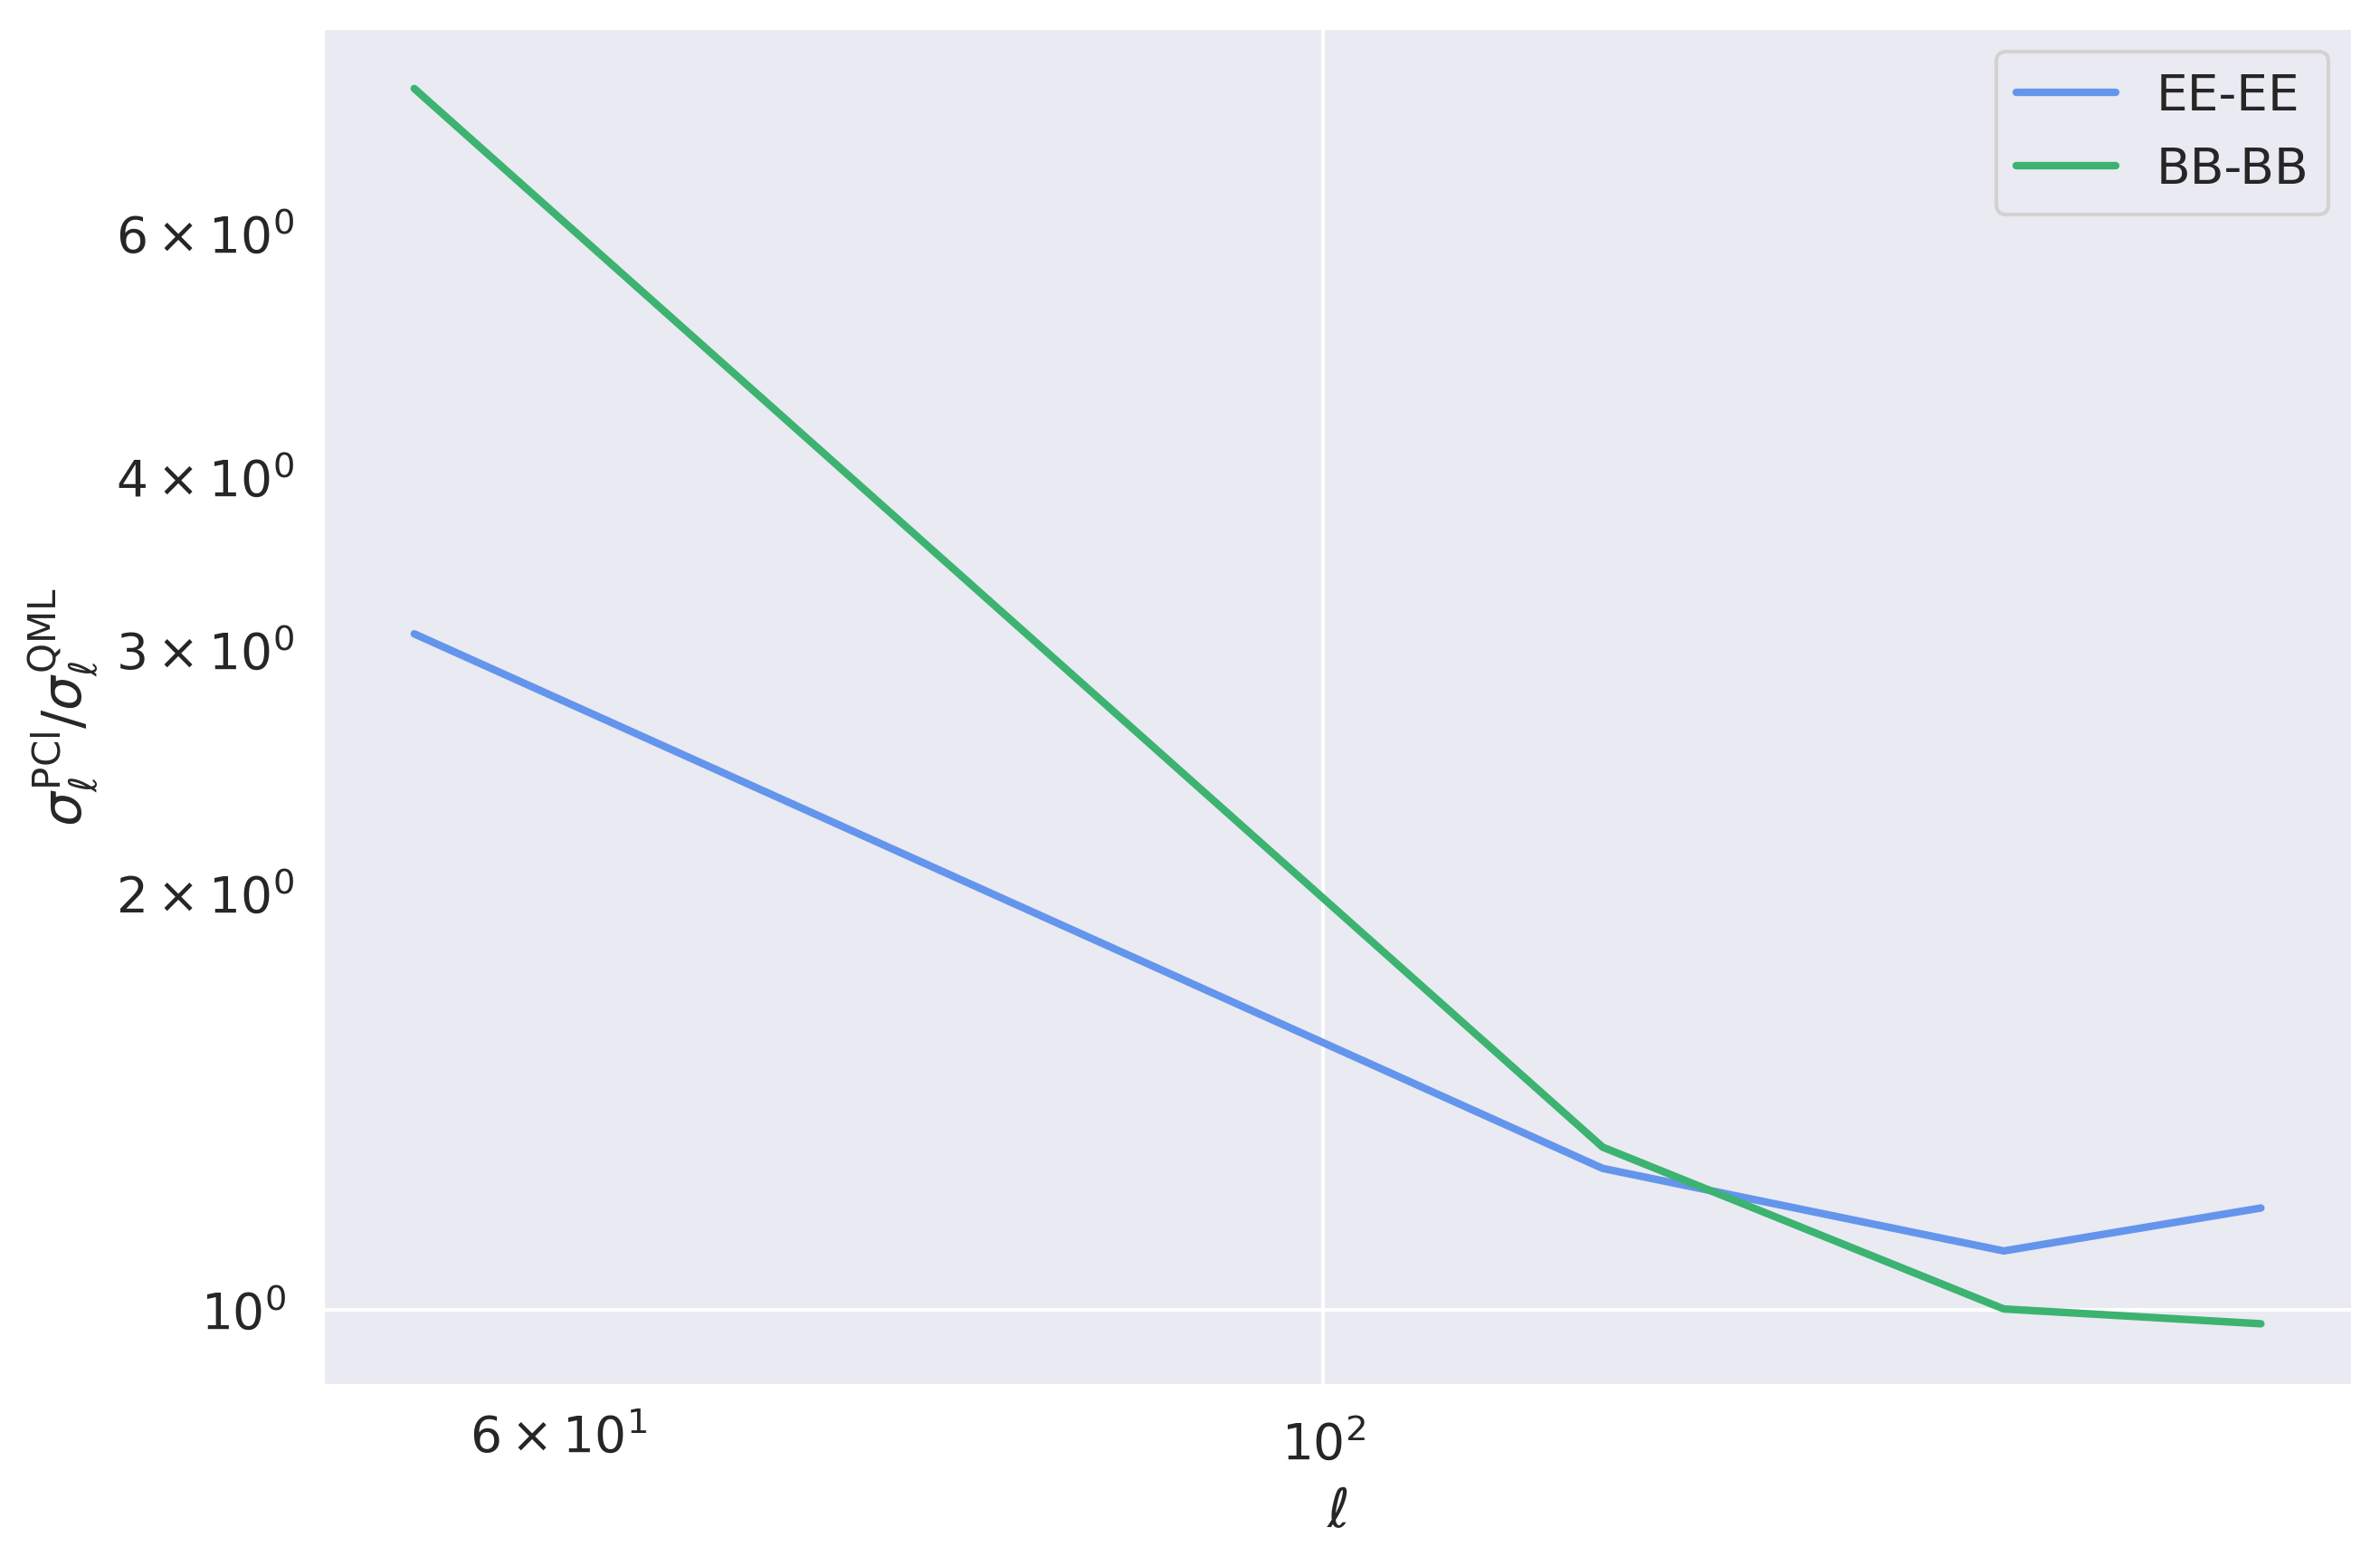

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ell_bp, np.sqrt(np.diag(cov_EE_EE_PCl / cov_EE_EE_QML)), c='cornflowerblue', lw=2, label='EE-EE')
ax.loglog(ell_bp, np.sqrt(np.diag(cov_BB_BB_PCl / cov_BB_BB_QML)), c='mediumseagreen', lw=2, label='BB-BB')

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\sigma_{\ell}^{\mathrm{PCl}} / \sigma_{\ell}^{\mathrm{QML}}$')

ax.legend()
plt.tight_layout()
plt.show()

## Now use the Fisher matrix to estimate the power spectrum of cosmic shear maps

With our Fisher matrix estimated, we can now use this to produce an estimate of the power spectrum for the set of cosmic shear maps that was produced above.

In [24]:
# Filepath to store the y_ell values in
y_ell_output = f'{tr1_data_dir}/y_ell_out_TR1_N{n_side}.dat'

# Execute the C++ code
cpp_lib.compute_power_spectrum(map_gamma1_path, map_gamma2_path, y_ell_output)

With the $y_{\ell}$ values computed, we can read them in and analyse them here

In [25]:
# Load the y_ell values
y_ell_QML = np.loadtxt(y_ell_output)

# Again, we have to delete any modes corresponding to EB spectra as we can't measure them
y_ell_QML = np.delete(y_ell_QML, np.s_[n_ell_full: 2 * n_ell_full], axis=0)

With our $y_{\ell}$ values and the inverse Fisher matrix, we can now compute estimates for the power spectrum coefficients $C_{\ell}$ for the QML estimator.

In [26]:
# Bin the y_ell values into the same bandpowers before combining with the (already binned) inverse Fisher matrix
y_ell_QML_binned = bin_matrix_EB @ y_ell_QML

cl_QML = inv_fisher_QML @ y_ell_QML_binned

# Extract specific components of the Cl values
cl_EE_QML = cl_QML[0: n_bands]
cl_BB_QML = cl_QML[n_bands: 2 * n_bands]

Now compute the PCl estimation of the power spectrum using NaMaster

In [27]:
field_shear = nmt.NmtField(mask, [map_gamma1, map_gamma2], lmax=bins.lmax)
cl_EE_PCl, cl_BB_PCl = nmt.compute_full_master(field_shear, field_shear, bins)[[0, 3]]

With our estimates of the power spectrum from our two methods, we can plot their results along with the theory curve that the maps were generated from to see how well they match and compare with each other.

In [28]:
# Load the heracles LE3 pipeline's own power spectra for the same tomographic bin, as an
# independent cross-check. Note this is heracles' raw (mode-coupled) pseudo-Cl product,
# not a deconvolved Cl like the QML/NaMaster estimates above, so treat it as a shape/scale
# sanity check rather than a strictly like-for-like comparison.
pipeline_cls_file = f'{pipeline_output_dir}/EUC_LE3_PKWL-SPECTRA-BINNED_1708440_20260414T135912.860079Z_26.02.fits'
cls_pipe = heracles.read(pipeline_cls_file)

she_she_pipe = cls_pipe['SHE', 'SHE', tom_bin, tom_bin]
ell_pipe = np.array(she_she_pipe.ell)
cl_EE_pipe = np.array(she_she_pipe[0, 0])
cl_BB_pipe = np.array(she_she_pipe[1, 1])

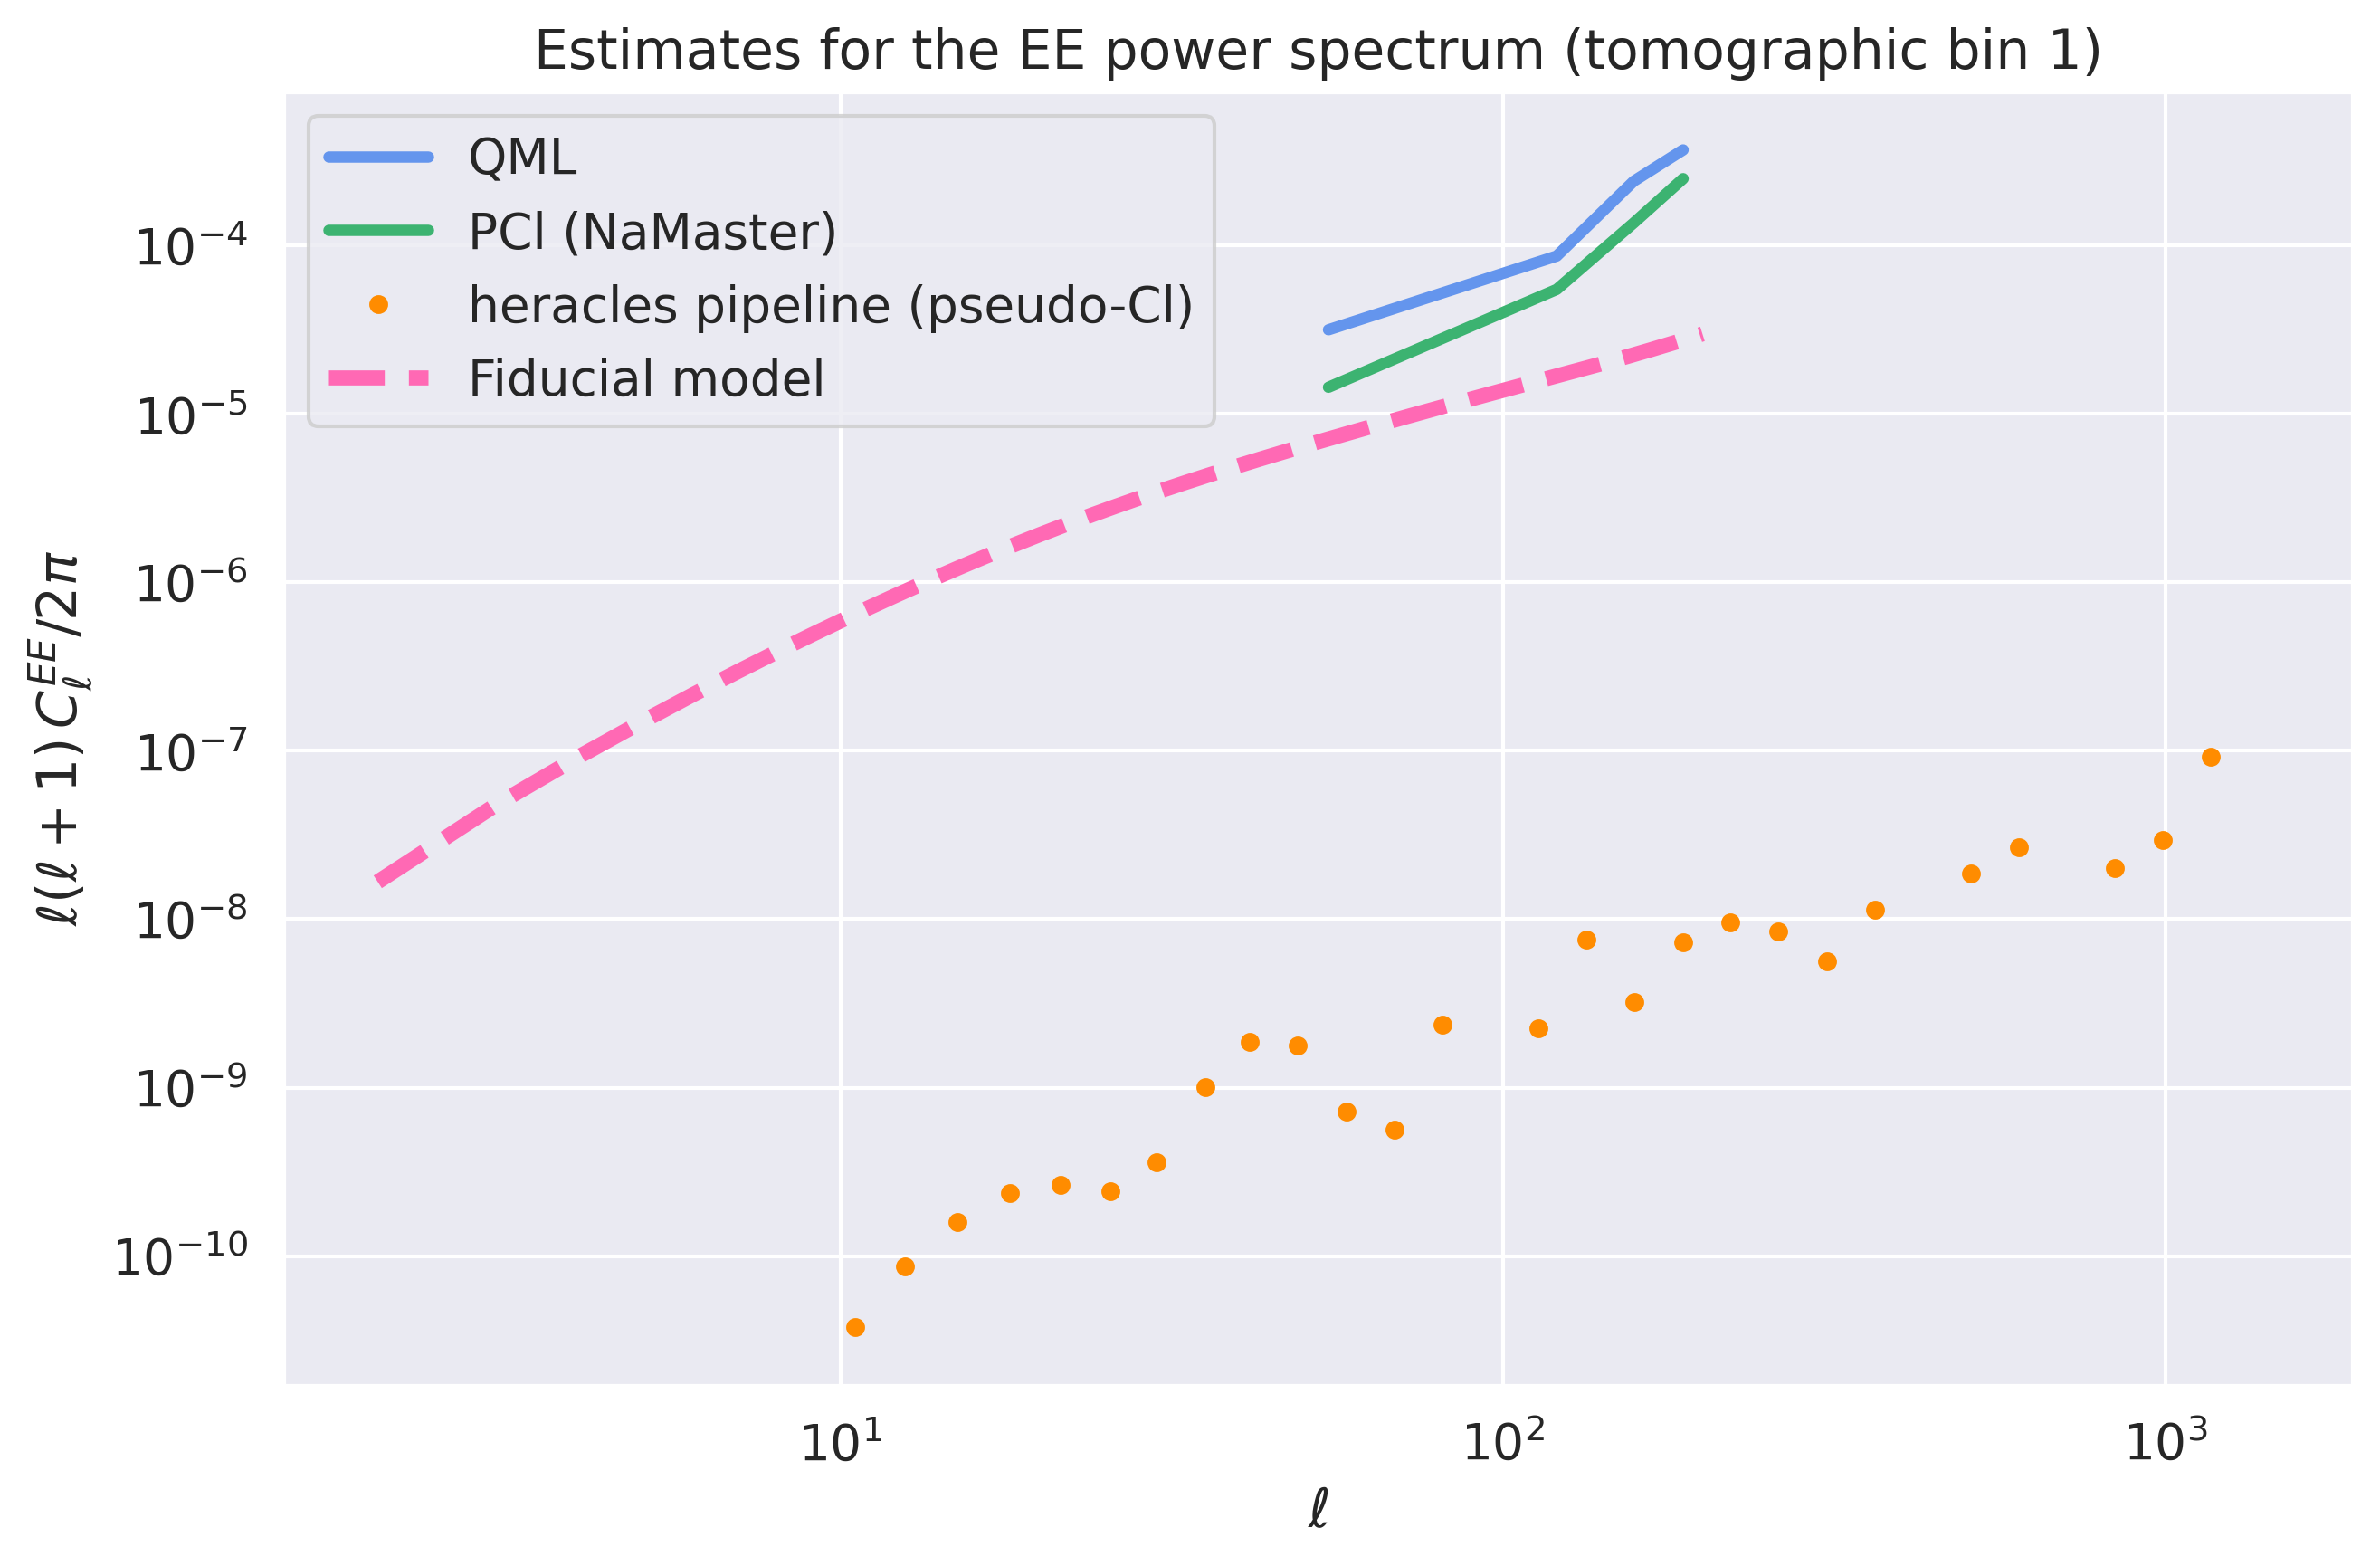

In [32]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * cl_EE_QML / (2 * np.pi), lw=3, c='cornflowerblue', label='QML')
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * cl_EE_PCl / (2 * np.pi), lw=3, c='mediumseagreen', label='PCl (NaMaster)')
ax.loglog(ell_pipe, ell_pipe * (ell_pipe + 1) * cl_EE_pipe / (2 * np.pi), 'o', ms=4, c='darkorange', label='heracles pipeline (pseudo-Cl)')

ax.loglog(ells, ells * (ells + 1) * (pow_spec.cl_EE[2: l_max + 1] + cl_noise) / (2 * np.pi), lw=4, ls='--', c='hotpink', label='Fiducial model')

ax.set_title(f'Estimates for the EE power spectrum (tomographic bin {tom_bin})')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()

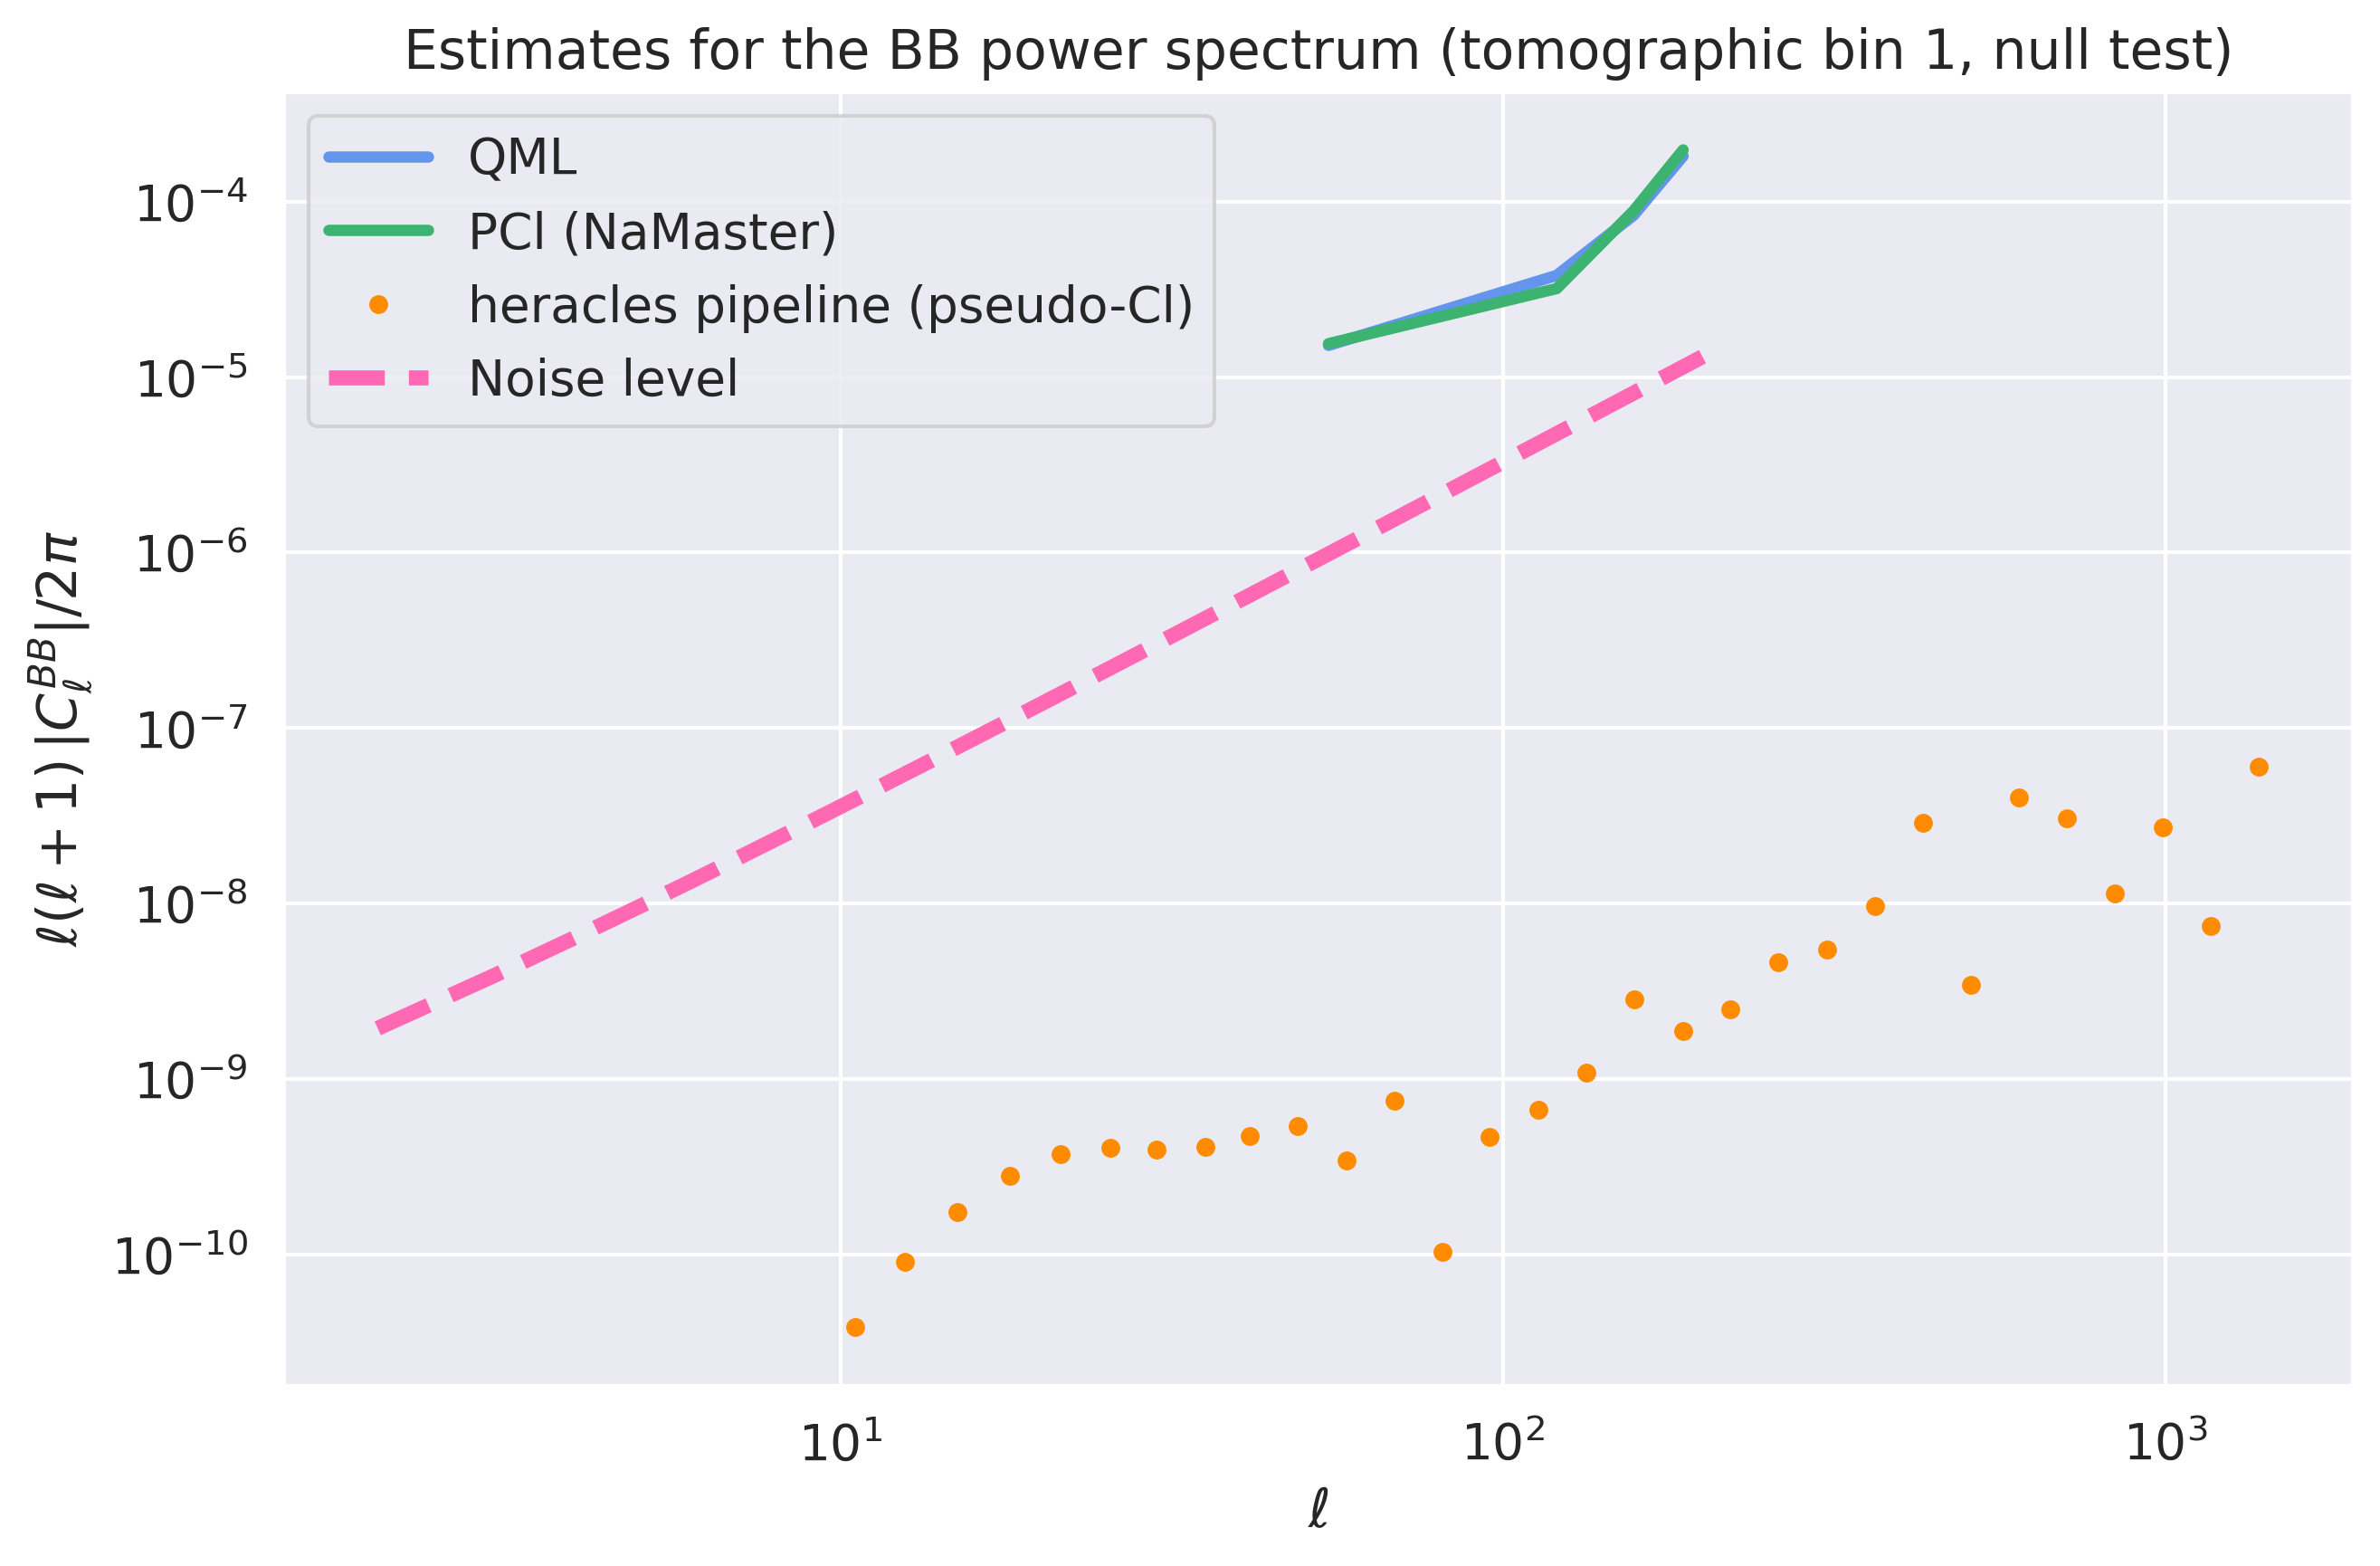

In [33]:
fix, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * np.abs(cl_BB_QML) / (2 * np.pi), lw=3, c='cornflowerblue', label='QML')
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * np.abs(cl_BB_PCl) / (2 * np.pi), lw=3, c='mediumseagreen', label='PCl (NaMaster)')
ax.loglog(ell_pipe, ell_pipe * (ell_pipe + 1) * np.abs(cl_BB_pipe) / (2 * np.pi), 'o', ms=4, c='darkorange', label='heracles pipeline (pseudo-Cl)')

ax.loglog(ells, ells * (ells + 1) * cl_noise / (2 * np.pi), lw=4, ls='--', c='hotpink', label='Noise level')

ax.set_title(f'Estimates for the BB power spectrum (tomographic bin {tom_bin}, null test)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, |C_{\ell}^{BB}| / 2 \pi$')

ax.legend()

plt.tight_layout()
plt.show()

The plots above compare the QML estimate directly against an independent NaMaster (PCl) estimate computed on the same real mask and shear map, as well as heracles' own pipeline pseudo-Cl product for the same tomographic bin (shown as points, on a different - mode-coupled - footing) and the fiducial model spectrum used to precondition the QML estimator. A close match between QML and NaMaster is the main correctness check here; agreement with heracles' pipeline output is a secondary, shape-level sanity check given the mode-coupling caveat above.

In [36]:
import fitsio as _fitsio

# Sanity check: is heracles' pseudo-Cl really just "coupled" (not mask-deconvolved), and does
# a *forward* mode-coupling of our own trusted fiducial spectrum land anywhere near its points?

# 1) Confirm heracles' own map-making metadata (nside/lmax/fsky used for THIS SHE-SHE product)
_hdr = _fitsio.read_header(pipeline_cls_file, ext=f'SHE-SHE-{tom_bin}-{tom_bin}')
print(f'heracles metadata for SHE-SHE-{tom_bin}-{tom_bin}:')
for key in ('META NSIDE_1', 'META LMAX_1', 'META DECONV_1', 'META FSKY_1', 'META WBAR_1', 'META DENS_1', 'META BIAS'):
    print(f'  {key} = {_hdr.get(key)}')
print(f'Our own real-mask f_sky = {f_sky:.6f}')

# 2) Forward-couple our trusted fiducial (signal+noise) spectrum with our own mask's coupling
# matrix `wsp`, then bin it the same way as the QML/PCl bandpowers, to see what a *coupled*
# (heracles-like) measurement of the SAME underlying sky should look like.
cl_theory_coupled = wsp.couple_cell([cl_EE + cl_noise, cl_EB, cl_EB, cl_BB + cl_noise])
cl_theory_coupled_EE_binned = bins.bin_cell(cl_theory_coupled[0])[0]

print('\nBandpower ell:            ', np.round(ell_bp, 1))
print('Coupled fiducial EE (pred):', cl_theory_coupled_EE_binned)
print('heracles EE (measured):    ', np.interp(ell_bp, ell_pipe, cl_EE_pipe))
print('Ratio (coupled_pred / heracles):', cl_theory_coupled_EE_binned / np.interp(ell_bp, ell_pipe, cl_EE_pipe))


heracles metadata for SHE-SHE-1-1:
  META NSIDE_1 = 1024
  META LMAX_1 = 1500
  META DECONV_1 = True
  META FSKY_1 = 0.00280917600262124
  META WBAR_1 = 692.496805928876
  META DENS_1 = 49548440.567966
  META BIAS = 4.03344793618826e-12
Our own real-mask f_sky = 0.003998

Bandpower ell:             [ 54.5 120.5 157.5 187. ]
Coupled fiducial EE (pred): 4.5991083933119455e-11
heracles EE (measured):     [2.58996712e-12 1.67050934e-12 8.45038274e-13 1.29951855e-12]
Ratio (coupled_pred / heracles): [17.75740066 27.53117444 54.42485314 35.39086362]


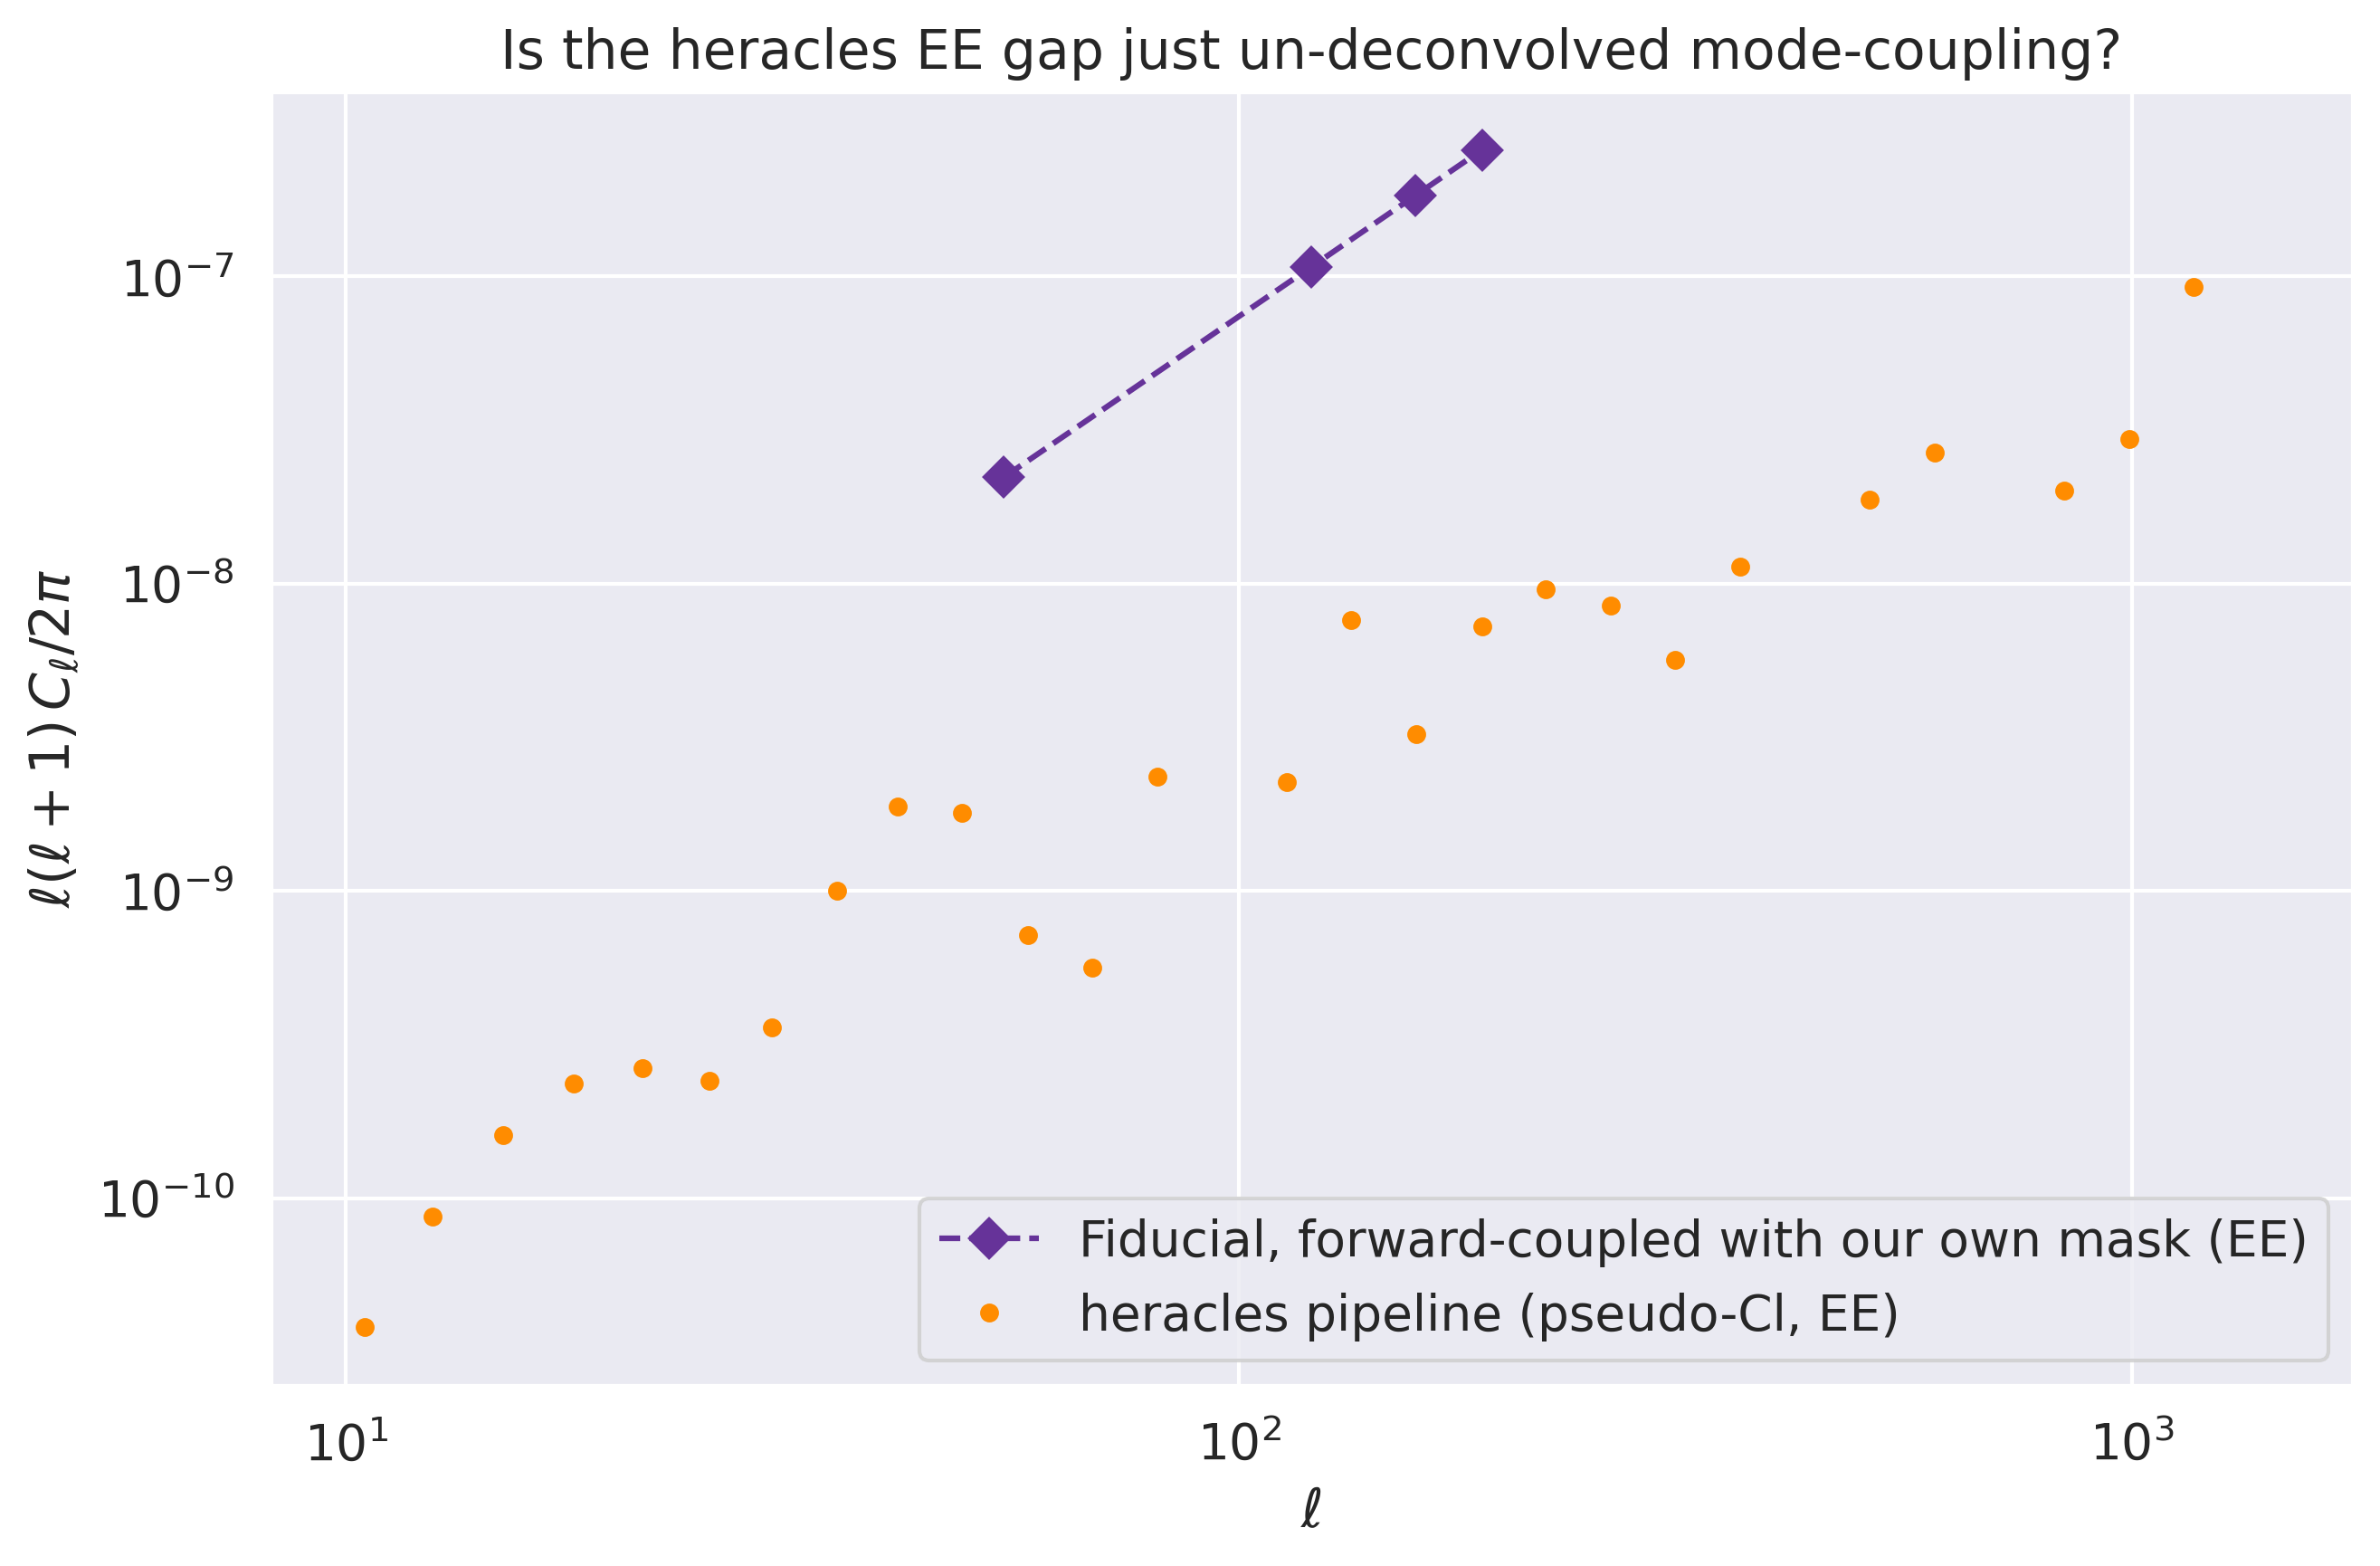

Same comparison, BB:
Coupled fiducial+noise BB (pred): 2.3582775115975084e-11
heracles BB (measured):           [ 9.22552136e-13 -6.78740839e-14  7.07951124e-13  3.35438588e-13]


In [37]:
cl_theory_coupled_BB_binned = bins.bin_cell(cl_theory_coupled[3])[0]

fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * cl_theory_coupled_EE_binned / (2 * np.pi),
          'D--', ms=7, c='rebeccapurple', label='Fiducial, forward-coupled with our own mask (EE)')
ax.loglog(ell_pipe, ell_pipe * (ell_pipe + 1) * cl_EE_pipe / (2 * np.pi),
          'o', ms=4, c='darkorange', label='heracles pipeline (pseudo-Cl, EE)')

ax.set_title('Is the heracles EE gap just un-deconvolved mode-coupling?')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell} / 2 \pi$')
ax.legend()
plt.tight_layout()
plt.show()

print('Same comparison, BB:')
print('Coupled fiducial+noise BB (pred):', cl_theory_coupled_BB_binned)
print('heracles BB (measured):          ', np.interp(ell_bp, ell_pipe, cl_BB_pipe))


In [47]:
print('Bandpower edges [ini, end):', list(zip(ell_bp_ini, ell_bp_end)))
print('Effective (weighted) bandpower centres:', ell_bp)
print('Modes in each bandpower:', [modes_per_ell[(ells_for_binning >= lo) & (ells_for_binning < hi)].sum()
                                     for lo, hi in zip(ell_bp_ini, ell_bp_end)])


Bandpower edges [ini, end): [(np.int64(10), np.int64(354)), (np.int64(354), np.int64(500)), (np.int64(500), np.int64(613)), (np.int64(613), np.int64(707)), (np.int64(707), np.int64(791)), (np.int64(791), np.int64(866)), (np.int64(866), np.int64(936)), (np.int64(936), np.int64(1001))]
Effective (weighted) bandpower centres: [181.5 426.5 556.  659.5 748.5 828.  900.5 968. ]
Modes in each bandpower: [np.float64(439.68707275390625), np.float64(437.8189926147461), np.float64(441.62889289855957), np.float64(435.6980895996094), np.float64(441.85011291503906), np.float64(436.3828182220459), np.float64(442.93163299560547), np.float64(442.10644721984863)]


In [39]:
n_modes_per_bin = np.array([modes_per_ell[(ells_for_binning >= lo) & (ells_for_binning < hi)].sum()
                            for lo, hi in zip(ell_bp_ini, ell_bp_end)])

# Rule-of-thumb fractional sample-variance scatter for a bin with N independent modes
rule_of_thumb_frac_err = np.sqrt(2 / n_modes_per_bin)

sigma_QML = np.sqrt(np.diag(cov_EE_EE_QML))
sigma_PCl = np.sqrt(np.diag(cov_EE_EE_PCl))

print('Modes/bin:                 ', np.round(n_modes_per_bin, 1))
print('Rule-of-thumb sigma/Cl:    ', np.round(rule_of_thumb_frac_err, 3))
print('QML measured sigma/Cl:     ', np.round(sigma_QML / cl_EE_QML, 3))
print('PCl (NaMaster) sigma/Cl:   ', np.round(sigma_PCl / cl_EE_PCl, 3))


Modes/bin:                  [39.6 40.6 40.4 40.5]
Rule-of-thumb sigma/Cl:     [0.225 0.222 0.222 0.222]
QML measured sigma/Cl:      [0.042 0.05  0.026 0.019]
PCl (NaMaster) sigma/Cl:    [0.283 0.1   0.051 0.034]


In [41]:

# Inverse check: instead of forward-coupling our theory, decouple heracles' own raw pseudo-Cl
# using OUR mask's (binned) mixing matrix, and see if it lands near the QML/PCl bandpowers.
# heracles bins its own points differently to us, so we first crudely resample its curve onto
# our bandpower centres before decoupling - this is only an order-of-magnitude check, since
# `wsp` was built from our own N128 approximation of the mask, not heracles' native N1024 one.
# decouple_cell wants a full per-ell (coupled) array, same shape as couple_cell's output,
# not the binned bandpowers - it does the binning internally before applying the inverse.
ells_dense = np.arange(bins.lmax + 1)
cl_EE_pipe_dense = np.interp(ells_dense, ell_pipe, cl_EE_pipe)
cl_BB_pipe_dense = np.interp(ells_dense, ell_pipe, cl_BB_pipe)
zeros_dense = np.zeros_like(cl_EE_pipe_dense)

cl_pipe_decoupled = wsp.decouple_cell([cl_EE_pipe_dense, zeros_dense, zeros_dense, cl_BB_pipe_dense])
cl_EE_pipe_decoupled = cl_pipe_decoupled[0]
cl_BB_pipe_decoupled = cl_pipe_decoupled[3]

print('Bandpower ell:                     ', np.round(ell_bp, 1))
print('heracles EE, decoupled with our M^-1:', cl_EE_pipe_decoupled)
print('QML EE:                             ', cl_EE_QML)
print('PCl (NaMaster) EE:                  ', cl_EE_PCl)
print('Ratio decoupled-heracles / QML:      ', cl_EE_pipe_decoupled / cl_EE_QML)
print('Ratio decoupled-heracles / PCl:      ', cl_EE_pipe_decoupled / cl_EE_PCl)


Bandpower ell:                      [ 54.5 120.5 157.5 187. ]
heracles EE, decoupled with our M^-1: [8.63953997e-10 3.92127884e-10 2.85591899e-10 4.50360089e-10]
QML EE:                              [6.53391704e-08 3.69725445e-08 6.03022790e-08 6.56375610e-08]
PCl (NaMaster) EE:                   [2.97800057e-08 2.34207819e-08 3.40730470e-08 4.43152771e-08]
Ratio decoupled-heracles / QML:       [0.0132226  0.01060592 0.00473601 0.00686132]
Ratio decoupled-heracles / PCl:       [0.02901121 0.01674273 0.00838175 0.01016264]
